<a href="https://colab.research.google.com/github/JaderBarbosaLSU/wellbore-thermal-storage/blob/main/THUMS_Multilayer_DoE_Dec_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install CoolProp

SINGLE- AND TWO-STAGE HEAT PUMPS: THERMODYNAMIC CYCLES

In [ ]:
import numpy as np
import CoolProp.CoolProp as CP
import matplotlib.pyplot as plt

def single_stage_htheatpump(refrig, T_1h, T_2h, DT_sub):
  """
  Calculates parameters for a single-stage high-temp heat pump.

  Args:
    refrig: The name of the refrigerant.
    T_1h: Temperature of state 1h in Kelvin.
    T_2h: Temperature of state 2h in Kelvin.
    DT_sub: Subcooling temperature difference in Celsius.

  Returns:
    A dictionary containing calculated Rankine cycle parameters,
    including enthalpy, entropy, pressure, and temperature for each state (1h, 2h, 3h, 4h),
    the HP COP, and saturation pressures.
  """
  # State 2h: Saturated Vapor at T_2h
  T_2h_kelvin = T_2h
  p_sat2h = CP.PropsSI('P', 'T', T_2h_kelvin, 'Q', 0, refrig) # Condensing pressure (at T_2h)
  p_2h = p_sat2h # Pressure at state 2h
  h_2h = CP.PropsSI('H', 'T', T_2h_kelvin, 'Q', 1, refrig)/1000.
  s_2h = CP.PropsSI('S', 'T', T_2h_kelvin, 'Q', 1, refrig)

  # State 3h: Saturated Liquid at (T_2h - DT_sub) and p_sat2h
  T_3h_kelvin = T_2h_kelvin - DT_sub
  p_3h = p_sat2h # Pressure at state 3h
  try:
      h_3h = CP.PropsSI('H', 'T', T_3h_kelvin, 'P', p_sat2h, refrig)/1000.
      s_3h = CP.PropsSI('S', 'T', T_3h_kelvin, 'P', p_sat2h, refrig)
  except ValueError:
       print(f"Warning: Could not calculate h_3h/s_3h for HP state 3h at T={T_3h_kelvin:.2f}K, P={p_sat2h:.2f}. Approximating.")
       # Fallback: Assume saturated liquid at T_3h_kelvin if subcooled state is problematic
       try:
            h_3h = CP.PropsSI('H', 'T', T_3h_kelvin, 'Q', 0, refrig)/1000.
            s_3h = CP.PropsSI('S', 'T', T_3h_kelvin, 'Q', 0, refrig)
       except ValueError:
            h_3h = np.nan
            s_3h = np.nan


  # State 1h: At T_1h_kelvin and p_sat1h (Evaporator Outlet)
  # Assuming State 1h is superheated vapor at the evaporator pressure (p_sat1h)
  T_1h_kelvin = T_1h
  p_sat1h = CP.PropsSI('P', 'T', T_1h_kelvin, 'Q', 0, refrig) # Evaporating pressure (at T_1h)
  p_1h = p_sat1h # Pressure at state 1h
  try:
      # State 1h is at T_1h and p_sat1h. Need to get other properties at this state.
      h_1h = CP.PropsSI('H', 'T', T_1h_kelvin, 'P', p_sat1h, refrig)/1000.
      s_1h = CP.PropsSI('S', 'T', T_1h_kelvin, 'P', p_sat1h, refrig)
  except ValueError:
      print(f"Warning: State 1h HP (T={T_1h_kelvin:.2f}K, P={p_sat1h:.2f}Pa) is outside valid region for {refrig}. Approximating with saturated vapor.")
      # Fallback to saturated vapor properties at T_1h_kelvin if superheated state is problematic
      try:
          h_1h = CP.PropsSI('H', 'T', T_1h_kelvin, 'Q', 1, refrig)/1000.
          s_1h = CP.PropsSI('S', 'T', T_1h_kelvin, 'Q', 1, refrig)
      except ValueError:
          h_1h = np.nan
          s_1h = np.nan


  # State 4h: Isenthalpic expansion from 3h to evaporator pressure (p_sat1h)
  h_4h = h_3h # Isenthalpic expansion from 3h
  p_4h = p_sat1h # Pressure at state 4h (same as state 1h)
  try:
      s_4h = CP.PropsSI('S', 'H', h_4h * 1000, 'P', p_4h, refrig) # Convert h_4h back to J/kg
      T_4h_kelvin = CP.PropsSI('T', 'H', h_4h * 1000, 'P', p_4h, refrig) # Convert h_4h back to J/kg
  except ValueError:
       print(f"Warning: Could not calculate s_4h/T_4h for HP state 4h at h={h_4h:.2f}kJ/kg, P={p_4h:.2f}Pa. Approximating.")
       s_4h = np.nan
       T_4h_kelvin = np.nan


  # HP COP
  # Ensure denominator is non-zero before division
  denominator_cop = (h_2h - h_1h)
  if abs(denominator_cop) > 1e-9:
      hp_cop = (h_2h - h_3h) / denominator_cop
  else:
      hp_cop = float('inf') # Assign a large value if denominator is zero or near zero


  return {
      'T_1h': T_1h_kelvin, 'p_1h': p_1h, 'h_1h': h_1h, 's_1h': s_1h,
      'T_2h': T_2h_kelvin, 'p_2h': p_2h, 'h_2h': h_2h, 's_2h': s_2h,
      'T_3h': T_3h_kelvin, 'p_3h': p_3h, 'h_3h': h_3h, 's_3h': s_3h,
      'T_4h': T_4h_kelvin, 'p_4h': p_4h, 'h_4h': h_4h, 's_4h': s_4h,
      'hp_cop': hp_cop,
      'p_sat1h': p_sat1h,
      'p_sat2h': p_sat2h
  }


def two_stage_htheatpump_2regs(refrig, T_13h, T_2h, DT_sub):
  """
  Calculates parameters for a two-stage high-temp heat pump with a liquid separator and 2 regenerators

  Args:
    refrig: The name of the refrigerant.
    T_13h: Temperature of state 13h in Kelvin.
    T_2h: Temperature of state 2h in Kelvin.
    DT_sub: Refrigerant subcooling degree at condenser outlet.

  Returns:
    A dictionary containing calculated Rankine cycle parameters.
  """
  # State 2h: Saturated Vapor at T_2h (Condenser Outlet)
  p_condh = CP.PropsSI('P', 'T', T_2h, 'Q', 0, refrig) # Condensing pressure
  p_2h = p_condh
  h_2h = CP.PropsSI('H', 'T', T_2h, 'Q', 1, refrig)/1000.
  s_2h = CP.PropsSI('S', 'T', T_2h, 'Q', 1, refrig)

  # State 3h: Subcooled Liquid at (T_2h - DT_sub) and p_condh (Condenser Outlet with subcooling)
  T_3h = T_2h - DT_sub
  p_3h = p_condh
  h_3h = CP.PropsSI('H', 'T', T_3h, 'P', p_condh, refrig)/1000.
  s_3h = CP.PropsSI('S', 'T', T_3h, 'P', p_condh, refrig)

  # State 13h: Saturated vapor at evaporating pressure
  p_evaph = CP.PropsSI('P', 'T', T_13h, 'Q', 1, refrig) # Evaporating pressure
  p_13h = p_evaph
  h_13h = CP.PropsSI('H', 'T', T_13h, 'Q', 1, refrig)/1000.
  s_13h = CP.PropsSI('S', 'T', T_13h, 'Q', 1, refrig)


  # Intermediate pressure
  p_inth = (p_evaph * p_condh)**(1./2.)

  # State 1h: At T_1h and p_evaph (Evaporator Outlet)
  s_1h = s_2h # Isentropic compression to 2h
  p_1h = p_evaph
  T_1h = CP.PropsSI('T', 'P', p_1h, 'S', s_1h, refrig)
  h_1h = CP.PropsSI('H', 'T', T_1h, 'P', p_evaph, refrig)/1000.

  # State 11h: Low pressure compressor outlet (p_inth, isentropic from 1h)
  s_11h = s_1h # Isentropic compression
  p_11h = p_inth
  T_11h = CP.PropsSI('T', 'S', s_11h, 'P', p_11h, refrig)
  h_11h = CP.PropsSI('H', 'S', s_11h, 'P', p_11h, refrig)/1000.

  # State 5h: Low Pressure Compressor outlet
  T_5h = T_11h
  p_5h = p_11h
  h_5h = h_11h
  s_5h = s_11h

  # State 6h: High Pressure Compressor inlet
  T_6h = T_11h
  p_6h = p_11h
  h_6h = h_11h
  s_6h = s_11h

  # State 9h
  p_9h = p_inth
  T_9h = CP.PropsSI('T', 'P', p_9h, 'Q', 0, refrig) # Saturated liquid temp at p_inth
  h_9h = CP.PropsSI('H', 'P', p_9h, 'Q', 0, refrig)/1000.
  s_9h = CP.PropsSI('S', 'P', p_9h, 'Q', 0, refrig)

  # State 10h
  p_10h = p_inth
  T_10h = CP.PropsSI('T', 'P', p_10h, 'Q', 1, refrig) # Saturated vapor temp at p_inth
  h_10h = CP.PropsSI('H', 'P', p_10h, 'Q', 1, refrig)/1000.
  s_10h = CP.PropsSI('S', 'P', p_10h, 'Q', 1, refrig)

  # State 14h
  p_14h = p_evaph
  T_14h = CP.PropsSI('T', 'P', p_14h, 'Q', 0, refrig) # Saturated liquid temp at p_evaph
  h_14h = CP.PropsSI('H', 'P', p_14h, 'Q', 0, refrig)/1000.
  s_14h = CP.PropsSI('S', 'P', p_14h, 'Q', 0, refrig)

  # IHX-1 effectiveness (based on T_3h and T_10h)
  # Ensure denominator is non-zero
  denominator_epsilon1 = (T_3h - T_10h)
  if abs(denominator_epsilon1) > 1e-9:
      epsilon_IHX_1 = (T_11h - T_10h) / denominator_epsilon1
  else:
      epsilon_IHX_1 = 1.0 # Assume 100% effectiveness if temperature difference is zero

  # CP_ratio_1:
  try:
      cpf_1 = CP.PropsSI('C', 'P', p_condh, 'Q', 0, refrig)
      cpv_1 = CP.PropsSI('C', 'P', p_inth, 'Q', 1, refrig)
      # Avoid division by zero
      if abs(cpf_1) > 1e-9:
           cpr_1 = cpv_1 / cpf_1
      else:
           cpr_1 = 1.0 # Assume ratio is 1 if cpf is zero
  except ValueError:
      print("Warning: Could not calculate cp for cpr_1 calculation. Setting cpr_1 to 1.0")
      cpr_1 = 1.0

  # Convergence loop for T_7h
  T_7h = T_3h - 4.  # initial guess for T_7h
  tol = 1e-4  # Tolerance for convergence
  max_iter = 100 # Maximum iterations
  p_7h = p_condh # State 7h is at condenser pressure

  for _ in range(max_iter):
      try:
          # Calculate h_7h based on current T_7h and p_7h
          h_7h_calc = CP.PropsSI('H', 'T', T_7h, 'P', p_7h, refrig)/1000.

          # State 8h: Flash Gas two-phase mixture (p_inth, h_8h=h_7h_calc)
          p_8h = p_inth
          h_8h_calc = h_7h_calc # Isenthalpic expansion from 7h
          # Ensure denominator is non-zero before calculating x_8h
          if abs(h_10h - h_9h) > 1e-9:
               x_8h_calc = (h_8h_calc - h_9h) / (h_10h - h_9h)
          else:
               x_8h_calc = 0.0 # If denominator is zero, assume quality is zero

          # Ensure x_8h_calc is within [0, 1] bounds
          x_8h_calc = max(0.0, min(1.0, x_8h_calc))

          # Calculate T_12h based on IHX-1 effectiveness
          T_12h_calc = T_3h - epsilon_IHX_1 * x_8h_calc * cpr_1 * (T_3h - T_10h)

          # IHX-2 effectiveness (based on T_1h and T_13h, and T_12h and T_13h)
          # Ensure denominator is non-zero
          denominator_epsilon2 = (T_12h_calc - T_13h)
          if abs(denominator_epsilon2) > 1e-9:
               epsilon_IHX_2_calc = (T_1h - T_13h) / denominator_epsilon2
          else:
               epsilon_IHX_2_calc = 1.0 # Assume 100% effectiveness if temperature difference is zero


          # CP_ratio_2:
          try:
              cpf_2 = CP.PropsSI('C', 'P', p_condh, 'Q', 0, refrig)
              cpv_2 = CP.PropsSI('C', 'P', p_evaph, 'Q', 1, refrig)
              # Avoid division by zero
              if abs(cpf_2) > 1e-9:
                   cpr_2_calc = cpv_2 / cpf_2
              else:
                   cpr_2_calc = 1.0 # Assume ratio is 1 if cpf is zero
          except ValueError:
              # print("Warning: Could not calculate cp for cpr_2 calculation. Setting cpr_2 to 1.0") # Commented out to avoid flooding output
              cpr_2_calc = 1.0

          # State 4h: two-phase mixture (p_evaph, h_4h=h_9h)
          p_4h = p_evaph
          h_4h_calc = h_9h # Isenthalpic expansion from 9h
          # Ensure denominator is non-zero before calculating x_4h
          if abs(h_13h - h_14h) > 1e-9:
              x_4h_calc = (h_4h_calc - h_14h) / (h_13h - h_14h)
          else:
               x_4h_calc = 0.0 # If denominator is zero, assume quality is zero

          # Ensure x_4h_calc is within [0, 1] bounds
          x_4h_calc = max(0.0, min(1.0, x_4h_calc))

          # Calculate T_7h_new based on IHX-2 effectiveness
          # Ensure denominator is non-zero before calculation
          if abs(cpr_2_calc * (T_12h_calc - T_13h)) > 1e-9:
               T_7h_new = T_12h_calc - epsilon_IHX_2_calc * x_4h_calc * cpr_2_calc * (T_12h_calc - T_13h)
          else:
               T_7h_new = T_7h # No change if denominator is zero

          # Check for convergence of T_7h
          if abs(T_7h_new - T_7h) < tol:
              T_7h = T_7h_new # Update T_7h to the converged value
              # After convergence, update all dependent state properties with the converged T_7h
              h_7h = h_7h_calc
              h_8h = h_8h_calc
              x_8h = x_8h_calc
              T_12h = T_12h_calc
              epsilon_IHX_2 = epsilon_IHX_2_calc
              cpr_2 = cpr_2_calc
              h_4h = h_4h_calc
              x_4h = x_4h_calc
              break # Exit the loop if converged

          T_7h = T_7h_new # Update guess for the next iteration

      except ValueError as e:
          print(f"Warning: CoolProp calculation failed in T_7h convergence loop: {e}. Breaking loop.")
          # Assign NaN to dependent properties on error and break
          h_7h, x_8h, T_12h, epsilon_IHX_2, cpr_2, h_4h, x_4h = np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
          break # Exit loop on CoolProp error

  else:
      print("Warning: Convergence for T_7h not achieved within max iterations.")
      # After max iterations without convergence, assign the values from the last iteration
      # Need to recalculate dependent variables one last time based on the final T_7h
      try:
          h_7h = CP.PropsSI('H', 'T', T_7h, 'P', p_7h, refrig)/1000.
          if abs(h_10h - h_9h) > 1e-9:
               x_8h = (h_7h - h_9h) / (h_10h - h_9h)
          else:
               x_8h = 0.0
          x_8h = max(0.0, min(1.0, x_8h))
          T_12h = T_3h - epsilon_IHX_1 * x_8h * cpr_1 * (T_3h - T_10h)
          denominator_epsilon2 = (T_12h - T_13h)
          if abs(denominator_epsilon2) > 1e-9:
               epsilon_IHX_2 = (T_1h - T_13h) / denominator_epsilon2
          else:
               epsilon_IHX_2 = 1.0
          try:
               cpf_2 = CP.PropsSI('C', 'P', p_condh, 'Q', 0, refrig)
               cpv_2 = CP.PropsSI('C', 'P', p_evaph, 'Q', 1, refrig)
               if abs(cpf_2) > 1e-9:
                    cpr_2 = cpv_2 / cpf_2
               else:
                    cpr_2 = 1.0
          except ValueError:
               cpr_2 = 1.0
          h_4h = h_9h
          if abs(h_10h - h_9h) > 1e-9:
              x_4h = (h_4h - h_9h) / (h_10h - h_9h)
          else:
               x_4h = 0.0
          x_4h = max(0.0, min(1.0, x_4h))

      except ValueError as e:
          print(f"Warning: Final CoolProp calculation failed after max iterations: {e}.")
          h_7h, x_8h, T_12h, epsilon_IHX_2, cpr_2, h_4h, x_4h = np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan


  # State 7h (using the converged T_7h)
  # h_7h and s_7h were calculated inside the loop, re-calculate if needed outside
  try:
       h_7h = CP.PropsSI('H', 'T', T_7h, 'P', p_7h, refrig)/1000.
       s_7h = CP.PropsSI('S', 'T', T_7h, 'P', p_7h, refrig)
  except ValueError:
       h_7h, s_7h = np.nan, np.nan


  # State 12h (using the converged T_12h)
  # T_12h was calculated inside the loop, re-calculate if needed outside
  try:
       p_12h = p_condh
       h_12h = CP.PropsSI('H', 'T', T_12h, 'P', p_12h, refrig)/1000.
       s_12h = CP.PropsSI('S', 'T', T_12h, 'P', p_12h, refrig)
  except ValueError:
       h_12h, s_12h = np.nan, np.nan


  # State 8h (using the converged h_8h=h_7h and p_8h=p_inth)
  # h_8h was calculated inside the loop, re-calculate if needed outside
  try:
       p_8h = p_inth
       T_8h = CP.PropsSI('T', 'P', p_8h, 'H', h_8h*1000., refrig)
       s_8h = CP.PropsSI('S', 'P', p_8h, 'H', h_8h*1000., refrig)
  except ValueError:
       T_8h, s_8h = np.nan, np.nan


  # State 4h (using the converged h_4h=h_9h and p_4h=p_evaph)
  # h_4h was calculated inside the loop, re-calculate if needed outside
  try:
       p_4h = p_evaph
       T_4h = CP.PropsSI('T', 'P', p_4h, 'H', h_4h*1000., refrig)
       s_4h = CP.PropsSI('S', 'P', p_4h, 'H', h_4h*1000., refrig)
  except ValueError:
       T_4h, s_4h = np.nan, np.nan


  # HP COP
  # Ensure denominator is non-zero before division and check for NaN values
  # Need to use the final converged x_8h and h_5h, h_1h
  denominator_cop = (h_2h - h_1h) - x_8h * (h_5h - h_1h)
  if abs(denominator_cop) > 1e-9 and not np.isnan(h_2h) and not np.isnan(h_1h) and not np.isnan(x_8h) and not np.isnan(h_5h):
      hp_cop = (h_2h - h_3h) / denominator_cop
  else:
      hp_cop = float('inf') # Assign a large value if denominator is zero or near zero or NaN


  return {
      'T_1h': T_1h, 'p_1h': p_1h, 'h_1h': h_1h, 's_1h': s_1h,
      'T_2h': T_2h, 'p_2h': p_2h, 'h_2h': h_2h, 's_2h': s_2h,
      'T_3h': T_3h, 'p_3h': p_3h, 'h_3h': h_3h, 's_3h': s_3h,
      'T_4h': T_4h, 'p_4h': p_4h, 'h_4h': h_4h, 's_4h': s_4h,
      'T_5h': T_5h, 'p_5h': p_5h, 'h_5h': h_5h, 's_5h': s_5h,
      'T_6h': T_6h, 'p_6h': p_6h, 'h_6h': h_6h, 's_6h': s_6h,
      'T_7h': T_7h, 'p_7h': p_7h, 'h_7h': h_7h, 's_7h': s_7h,
      'T_8h': T_8h, 'p_8h': p_8h, 'h_8h': h_8h, 's_8h': s_8h,
      'T_9h': T_9h, 'p_9h': p_9h, 'h_9h': h_9h, 's_9h': s_9h,
      'T_10h': T_10h, 'p_10h': p_10h, 'h_10h': h_10h, 's_10h': s_10h,
      'T_11h': T_11h, 'p_11h': p_11h, 'h_11h': h_11h, 's_11h': s_11h,
      'T_12h': T_12h, 'p_12h': p_12h, 'h_12h': h_12h, 's_12h': s_12h,
      'T_13h': T_13h, 'p_13h': p_13h, 'h_13h': h_13h, 's_13h': s_13h,
      'hp_cop': hp_cop,
      'p_evaph': p_evaph,
      'p_condh': p_condh, # Changed from p_evaph to p_condh
      'p_inth': p_inth,
      'epsilon_IHX_1': epsilon_IHX_1,
      'epsilon_IHX_2': epsilon_IHX_2,
      'x_8h': x_8h,
  }

# @title
#import numpy as np
#import CoolProp.CoolProp as CP
#import matplotlib.pyplot as plt

def carnot_efficiency(T_hot, T_cold):
  """
  Calculates the Carnot cycle efficiency.

  Args:
    T_hot: Temperature of the hot reservoir in kelvin.
    T_cold: Temperature of the cold reservoir in kelvin.

  Returns:
    The Carnot efficiency as a value between 0 and 1.
  """
  # Calculate Carnot efficiency
  efficiency = 1 - (T_cold / T_hot)

  return efficiency


SINGLE- AND TWO-STAGE ORCs: THERMODYNAMIC CYCLES

In [ ]:
# @title
def single_stage_rankine(fluid, T_1e, T_3e):
  """
  Calculates parameters for a single-stage Rankine cycle.

  Args:
    fluid: The name of the working fluid.
    T_1e: Temperature of state 1e in Kelvin.
    T_3e: Temperature of state 3e in Kelvin.

  Returns:
    A dictionary containing calculated Rankine cycle parameters,
    including enthalpy, entropy, temperature, and pressure for each state,
    the Rankine efficiency, and saturation pressures.
  """
  # State 1e: Saturated liquid at T_1e (Evaporator Inlet)
  p_sat1e = CP.PropsSI('P', 'T', T_1e, 'Q', 0, fluid) # Evaporator pressure
  p_1e = p_sat1e
  h_1e = CP.PropsSI('H', 'T', T_1e, 'Q', 0, fluid)/1000.
  s_1e = CP.PropsSI('S', 'T', T_1e, 'Q', 0, fluid)


  # State 2e: Isentropic compression from 1e to condenser pressure (p_sat3e)
  s_2e = s_1e
  p_sat3e = CP.PropsSI('P', 'T', T_3e, 'Q', 1, fluid) # Condenser pressure (same as 3e)
  p_2e = p_sat3e
  try:
      h_2e = CP.PropsSI('H', 'S', s_2e, 'P', p_2e, fluid)/1000.
      T_2e = CP.PropsSI('T', 'S', s_2e, 'P', p_2e, fluid)
  except ValueError:
       print(f"Warning: Could not calculate h_2e/T_2e for Rankine cycle at s={s_2e:.2f}, P={p_2e:.2f}. Setting to NaN.")
       h_2e = np.nan
       T_2e = np.nan


  # State 3e: Saturated vapor at T_3e (Evaporator Outlet)
  p_3e = p_sat3e
  h_3e = CP.PropsSI('H', 'T', T_3e, 'Q', 1, fluid)/1000.
  s_3e = CP.PropsSI('S', 'T', T_3e, 'Q', 1, fluid)


  # State 4e: Isenthalpic expansion from 3e to evaporator pressure (p_sat1e)
  # Assuming isenthalpic expansion based on typical Rankine cycle
  h_4e = h_1e # Isenthalpic expansion from 1e to 4e? No, from 3e to 4e is isentropic expansion in ideal Rankine.
  # Re-calculating state 4e based on isentropic expansion from 3e as per standard Rankine
  s_4e = s_3e
  p_4e = p_sat1e # Same pressure as state 1e (Evaporator Pressure)
  try:
      h_4e = CP.PropsSI('H', 'S', s_4e, 'P', p_4e, fluid)/1000.
      T_4e = CP.PropsSI('T', 'S', s_4e, 'P', p_4e, fluid)
  except ValueError:
      print(f"Warning: Could not calculate h_4e/T_4e for Rankine cycle at s={s_4e:.2f}, P={p_4e:.2f}. Setting to NaN.")
      h_4e = np.nan
      T_4e = np.nan

  # Rankine efficiency
  # Ensure denominator is non-zero before division
  denominator_eff = (h_3e - h_2e)
  if abs(denominator_eff) > 1e-9:
      rank_eff = ((h_3e - h_4e)-(h_2e - h_1e)) / denominator_eff
  else:
      rank_eff = float('inf') # Assign large value if denominator is zero or near zero


  return {
      'T_1e': T_1e, 'p_1e': p_1e, 'h_1e': h_1e, 's_1e': s_1e,
      'T_2e': T_2e, 'p_2e': p_2e, 'h_2e': h_2e, 's_2e': s_2e,
      'T_3e': T_3e, 'p_3e': p_3e, 'h_3e': h_3e, 's_3e': s_3e,
      'T_4e': T_4e, 'p_4e': p_4e, 'h_4e': h_4e, 's_4e': s_4e,
      'rank_eff': rank_eff,
      'p_sat1e': p_sat1e,
      'p_sat3e': p_sat3e
  }


def double_stage_rankine(fluid, T_1e, T_3e):
  """
  Calculates parameters for a two-stage Rankine cycle with regeneration/reheating

  Args:
    fluid: The name of the working fluid.
    T_1e: Temperature of state 1e in Kelvin.
    T_3e: Temperature of state 3e in Kelvin.

  Returns:
    A dictionary containing calculated Rankine cycle parameters,
    including enthalpy, entropy, temperature, and pressure for each state,
    the Rankine efficiency, and saturation pressures.
  """
  # State 3e: Saturated vapor at the 1st stage (turbine) inlet
  p_evape = CP.PropsSI('P', 'T', T_3e, 'Q', 1, fluid) # Condenser pressure (same as 3e)
  p_3e = p_evape
  h_3e = CP.PropsSI('H', 'T', T_3e, 'Q', 1, fluid)/1000.
  s_3e = CP.PropsSI('S', 'T', T_3e, 'Q', 1, fluid)

  # State 1e: Saturated liquid at condenser outlet
  p_conde = CP.PropsSI('P', 'T', T_1e, 'Q', 0, fluid) # Evaporator pressure
  p_1e = p_conde
  h_1e = CP.PropsSI('H', 'T', T_1e, 'Q', 0, fluid)/1000.
  s_1e = CP.PropsSI('S', 'T', T_1e, 'Q', 0, fluid)

  # Intermediate pressure
#  p_inte = (p_evape * p_conde)**(1./2.)
  p_inte = (p_evape + p_conde)*(1./2.)

  # State 5e: 1st stage turbine outlet
  p_5e = p_inte
  s_5e = s_3e
  h_5e = CP.PropsSI('H', 'S', s_5e, 'P', p_5e, fluid)/1000.
  T_5e = CP.PropsSI('T', 'S', s_5e, 'P', p_5e, fluid)

  # State 6e: 2nd stage turbine inlet
  p_6e = p_5e
  T_6e = T_3e #ideal reheat
  h_6e = CP.PropsSI('H', 'T', T_6e, 'P', p_6e, fluid)/1000.
  s_6e = CP.PropsSI('S', 'T', T_6e, 'P', p_6e, fluid)

  # State 4e: 2nd stage turbine outlet
  p_4e = p_conde
  s_4e = s_6e
  h_4e = CP.PropsSI('H', 'S', s_4e, 'P', p_4e, fluid)/1000.
  T_4e = CP.PropsSI('T', 'S', s_4e, 'P', p_4e, fluid)

  # State 2e: Pump 1 outlet
  p_2e = p_evape
  s_2e = s_1e
  h_2e = CP.PropsSI('H', 'S', s_2e, 'P', p_2e, fluid)/1000.
  T_2e = CP.PropsSI('T', 'S', s_2e, 'P', p_2e, fluid)

  # State 7e: Pump 2 inlet
  p_7e = p_inte
  h_7e = CP.PropsSI('H', 'P', p_7e, 'Q', 0, fluid)/1000.
  s_7e = CP.PropsSI('S', 'P', p_7e, 'Q', 0, fluid)
  T_7e = CP.PropsSI('T', 'P', p_7e, 'Q', 0, fluid)

  # State 8e: Pump 2 outlet
  p_8e = p_evape
  s_8e = s_7e
  h_8e = CP.PropsSI('H', 'P', p_8e, 'S', s_8e, fluid)/1000.
  T_8e = CP.PropsSI('T', 'P', p_8e, 'S', s_8e, fluid)

  # State 9e:
  p_9e = p_evape
  T_9e = T_7e
  h_9e = CP.PropsSI('H', 'T', T_9e, 'P', p_9e, fluid)/1000.
  s_9e = CP.PropsSI('S', 'T', T_9e, 'P', p_9e, fluid)

  # Energy balance in the regenerator
  y_frac = (h_5e - h_7e) / ((h_9e - h_2e) + (h_5e - h_7e))

  # State 10e:
  p_10e = p_evape
  h_10e = y_frac * h_9e + (1. - y_frac) * h_8e
  s_10e = CP.PropsSI('S', 'H', h_10e*1000, 'P', p_10e, fluid)
  T_10e = CP.PropsSI('T', 'H', h_10e*1000, 'P', p_10e, fluid)

  # cycle thermal efficiency
  numerator_eff = (h_3e - h_10e) + y_frac * (h_6e - h_5e) - y_frac * (h_4e - h_1e)
  denominator_eff = (h_3e - h_10e) + y_frac * (h_6e - h_5e)
  if abs(denominator_eff) > 1e-9:
      rank_eff = numerator_eff / denominator_eff
  else:
      rank_eff = float('inf') # Assign large value if denominator is zero or near zero

  return {
      'T_1e': T_1e, 'p_1e': p_1e, 'h_1e': h_1e, 's_1e': s_1e,
      'T_2e': T_2e, 'p_2e': p_2e, 'h_2e': h_2e, 's_2e': s_2e,
      'T_3e': T_3e, 'p_3e': p_3e, 'h_3e': h_3e, 's_3e': s_3e,
      'T_4e': T_4e, 'p_4e': p_4e, 'h_4e': h_4e, 's_4e': s_4e,
      'T_5e': T_5e, 'p_5e': p_5e, 'h_5e': h_5e, 's_5e': s_5e,
      'T_6e': T_6e, 'p_6e': p_6e, 'h_6e': h_6e, 's_6e': s_6e,
      'T_7e': T_7e, 'p_7e': p_7e, 'h_7e': h_7e, 's_7e': s_7e,
      'T_8e': T_8e, 'p_8e': p_8e, 'h_8e': h_8e, 's_8e': s_8e,
      'T_9e': T_9e, 'p_9e': p_9e, 'h_9e': h_9e, 's_9e': s_9e,
      'T_10e': T_10e, 'p_10e': p_10e, 'h_10e': h_10e, 's_10e': s_10e,
      'rank_eff': rank_eff,
      'p_evape': p_evape,
      'p_conde': p_conde,
      'p_inte': p_inte,
      'y_frac': y_frac # Added y_frac to the return dictionary
  }

PLOTTING FUNCTIONS: BOREHOLE BATTERY HEAT EXCHANGER GEOMETRY

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np
from math import pi, cos, sin

def distribute_longitudinal_fins2(D_i, D_e, fin_thickness, fin_length, num_fins, center_x, center_y):
    """
    Calculates the coordinates and angles for distributing rectangular
    longitudinal fins around the periphery of a tube, centered at (center_x, center_y).

    Args:
        D_i: Internal diameter of the tube [m].
        D_e: External diameter of the tube [m].
        fin_thickness: Thickness of each fin [m].
        fin_length: Length of each fin extending radially outwards [m].
        num_fins: The number of fins to distribute.
        center_x: The x-coordinate of the tube's center.
        center_y: The y-coordinate of the tube's center.

    Returns:
        A tuple containing:
            - fin_angles: Array of angles (in radians) representing the center
                          of each fin relative to the tube center.
            - fin_coords: List of arrays, where each array contains the
                          (x, y) coordinates of the four corners of a fin.
    """
    r_e = D_e / 2.0
    r_tip = r_e + fin_length
    fin_half_thickness_rad = np.arctan((fin_thickness / 2.0) / r_e)

    # Angles for the center of each fin
    fin_angles = np.linspace(0, 2 * pi, num_fins, endpoint=False)

    fin_coords = []
    for angle in fin_angles:
        # Calculate the four corners of the fin in polar coordinates relative to the tube center
        angle1 = angle - fin_half_thickness_rad
        angle2 = angle + fin_half_thickness_rad

        r1 = r_e
        r2 = r_tip

        # Convert polar to Cartesian coordinates and offset by the tube center
        x1 = center_x + r1 * cos(angle1)
        y1 = center_y + r1 * sin(angle1)

        x2 = center_x + r1 * cos(angle2)
        y2 = center_y + r1 * sin(angle2)

        x3 = center_x + r2 * cos(angle2)
        y3 = center_y + r2 * sin(angle2)

        x4 = center_x + r2 * cos(angle1)
        y4 = center_y + r2 * sin(angle1)

        fin_coords.append(np.array([[x1, y1], [x2, y2], [x3, y3], [x4, y4]]))

    return fin_angles, fin_coords


def plot_double_casing_finned3(geom_par_vector):
    """
    Draws a large circle (wellbore) of diameter D_well and finned tubes
    inside. The number of tubes is determined by num_tubes (1 for two tubes,
    2 for four tubes). The tubes are identical with inner diameter D_i_tube
    and outer diameter D_e_tube, fin_thickness, fin_length, and num_fins.
    The arrangement of tubes depends on num_tubes.

    Args:
        geom_par_vector: An array or list containing [L_well, L_tube, D_well, r_i, r_e, D_i_tube, D_e_tube, fin_t, fin_L, num_fins, num_tubes].
    """
    # Unpack the parameters from the vector
    L_well, L_tube, D_well, r_i, r_e, D_i_tube, D_e_tube, fin_t, fin_L, num_fins, num_tubes = geom_par_vector

    r_well = D_well / 2.0
    r_tip_tube = r_e + fin_L

    centers = []
    center_lines_x = []
    center_lines_y = []

    # Calculate the required offset for the four-tube arrangement first,
    # as this will determine the spacing for the two-tube arrangement.
    clearance = 0.01 # meters, minimum clearance between fin tips and wellbore
    offset_four_tubes = r_well - r_tip_tube - clearance

    if offset_four_tubes < 0:
         raise ValueError("Finned tubes with this fin length are too large for the wellbore, even without spacing.")

    # Check for potential overlap between fin tips of adjacent tubes in the four-tube case
    distance_between_adjacent_centers_four_tubes = offset_four_tubes * np.sqrt(2)
    if distance_between_adjacent_centers_four_tubes < 2 * r_tip_tube:
         raise ValueError(
            f"Finned tubes with this fin length and wellbore size are too close for the four-tube arrangement. "
            f"Increase wellbore diameter or decrease fin length/tube outer diameter."
        )

    # The distance between adjacent tubes in the four-tube case is distance_between_adjacent_centers_four_tubes.
    # We want the distance between the two tubes in the two-tube case to be this same distance.
    # For two tubes centered at (-x_offset, 0) and (x_offset, 0), the distance between centers is 2 * x_offset.
    # So, 2 * x_offset = distance_between_adjacent_centers_four_tubes
    # x_offset_two_tubes = distance_between_adjacent_centers_four_tubes / 2.0


    if num_tubes == 1:
        # Set the distance between centers for the two tubes
        # This is the distance between adjacent centers in the four-tube case
        d_two_tubes = distance_between_adjacent_centers_four_tubes
        x_offset = d_two_tubes / 2.0
        centers = [(-x_offset, 0), (x_offset, 0)]
        center_lines_x = [-x_offset, x_offset]
        center_lines_y = [0, 0]

        # Check if the finned tubes fit in the wellbore for two tubes with this spacing
        max_finned_radius_from_well_center_two_tubes = x_offset + r_tip_tube
        if max_finned_radius_from_well_center_two_tubes > r_well:
             raise ValueError(
                f"Finned tubes with the specified spacing ({d_two_tubes:.3f} m) do not fit in the wellbore ({D_well:.3f} m diameter)."
            )


    elif num_tubes == 2:
        # Use the previously calculated offset for the four-tube arrangement
        offset = offset_four_tubes
        centers = [(offset, 0), (-offset, 0), (0, offset), (0, -offset)]
        # Sort centers based on their position relative to the diagonal y=x
        # Points (x,y) with y > x are above the line, y < x are below. For y=x line, we can check y-x.
        # For the given centers:
        # (offset, 0): 0 - offset < 0 (below)
        # (-offset, 0): 0 - (-offset) = offset > 0 (above)
        # (0, offset): offset - 0 = offset > 0 (above)
        # (0, -offset): -offset - 0 = -offset < 0 (below)
        # So, (-offset, 0) and (0, offset) are above the line y=x.
        # (offset, 0) and (0, -offset) are below the line y=x.

        centers_above = [(x, y) for x, y in centers if y >= x]
        centers_below = [(x, y) for x, y in centers if y < x]

        # Ensure the centers are sorted consistently for plotting lines
        centers_above.sort()
        centers_below.sort()


        center_lines_x = [-offset, offset, 0, 0]
        center_lines_y = [0, 0, -offset, offset]
        # No single connecting line for four tubes, will draw axis lines instead

        # Check if the finned tubes fit in the wellbore for four tubes
        max_finned_radius_from_well_center_four_tubes = offset + r_tip_tube
        if max_finned_radius_from_well_center_four_tubes > r_well:
             # This should theoretically not happen with the offset calculation, but good to have
             raise ValueError(
                 f"Finned tubes do not fit in the wellbore for the four-tube arrangement. "
                 f"Max fin radius from well center: {max_finned_radius_from_well_center_four_tubes:.3f} m > "
                 f"Wellbore radius: {r_well:.3f} m"
             )

    else:
        raise ValueError("num_tubes must be 1 (for two tubes) or 2 (for four tubes).")


    fig, ax = plt.subplots(figsize=(8,8))

    # Draw the large wellbore circle
    wellbore = plt.Circle((0, 0), r_well, color='b', fill=False, linewidth=2, label='Wellbore')
    ax.add_patch(wellbore)

    # Draw the finned tubes (internal and external circles and fins)
    for idx, (xc, yc) in enumerate(centers):
        # Draw internal diameter circle
        internal_circle = plt.Circle((xc, yc), r_i, color='blue', fill=False, linewidth=1, linestyle='--')
        ax.add_patch(internal_circle)

        # Draw external diameter circle
        external_circle = plt.Circle((xc, yc), r_e, color='red', fill=False, linewidth=1)
        ax.add_patch(external_circle)

        # Draw the fins
        fin_angles, fin_coords = distribute_longitudinal_fins2(D_i_tube, D_e_tube, fin_t, fin_L, num_fins, xc, yc)
        for fin in fin_coords:
            fin_patch = plt.Polygon(fin, closed=True, facecolor='gray', edgecolor='black', linewidth=0.5)
            ax.add_patch(fin_patch)

    # Draw the center lines
    if num_tubes == 1:
         ax.plot(center_lines_x, center_lines_y, 'k--', lw=1)
    elif num_tubes == 2:
         # Connect nearest tube centers on opposite sides of the diagonal line with dotted lines
         # Assuming centers_above are [(-offset, 0), (0, offset)] and centers_below are [(offset, 0), (0, -offset)]
         if len(centers_above) == 2 and len(centers_below) == 2:
             # Connect (-offset, 0) to (offset, 0)
             ax.plot([centers_above[0][0], centers_below[0][0]], [centers_above[0][1], centers_below[0][1]], 'k:', lw=1)
             # Connect (0, offset) to (0, -offset)
             ax.plot([centers_above[1][0], centers_below[1][0]], [centers_above[1][1], centers_below[1][1]], 'k:', lw=1)


         # Draw a thick diagonal line across the wellbore, limited by the wellbore radius
         # The diagonal line is y = x. Intersects the circle x^2 + y^2 = r_well^2
         # x^2 + x^2 = r_well^2 => 2x^2 = r_well^2 => x = +/- r_well / sqrt(2)
         # y = x, so the endpoints are (-r_well/sqrt(2), -r_well/sqrt(2)) and (r_well/sqrt(2), r_well/sqrt(2))
         r_diag = r_well / np.sqrt(2)
         ax.plot([-r_diag, r_diag], [-r_diag, r_diag], 'k-', lw=3)


    # Mark centers
    ax.plot([0], [0], 'bo', label='Wellbore Center')
    # Plot individual tube centers
    tube_centers_x = [c[0] for c in centers]
    tube_centers_y = [c[1] for c in centers]
    ax.plot(tube_centers_x, tube_centers_y, 'ro', label='Tube Center')


    # Formatting
    ax.set_aspect('equal', 'box')
    # Adjust limits to accommodate the fins and arrangement
    limit = r_well + 0.1 * r_well # Add some padding outside the wellbore
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    title_text = f'Wellbore and Finned Tube Geometry ({num_tubes} hairpins)'
    ax.set_title(title_text)


    # Create legend - might need manual handling to avoid too many legend entries for fins
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    # Select which items to include in the legend
    legend_elements = [
        by_label['Wellbore'],
        by_label['Tube Center']
    ]
    # You might want to add a representative patch for the finned tubes if needed

    ax.legend(handles=legend_elements)


    plt.tight_layout()
    plt.show()

PLOTTING FUNCTIONS: SINGLE-STAGE ORC AND TWO-STAGE HTHP

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np
import CoolProp.CoolProp as CP

def plot_combined_ts_diagram(rankine_params, hpheatpump_params, rankine_fluid, hp_refrigerant, T_2d_kelvin, T_3d_kelvin, T_3a_kelvin, T_4a_kelvin, T_2c_kelvin, T_3c_kelvin):
    """
    Plots the Temperature-Entropy (T-s) diagrams for both the Rankine cycle
    and the Heat Pump cycle on a single plot, including the saturation lines
    for both working fluids. Temperatures are plotted in degrees Celsius.

    Args:
        rankine_params: Dictionary containing the Rankine cycle state point data
                        (T, p, h, s for states 1e, 2e, 3e, 4e).
        hpheatpump_params: Dictionary containing the Heat Pump cycle state point data
                           (T, p, h, s for states 1h, 2h, 3h, 4h, and potentially others
                           like 5h, 6h, 7h, 8h, 9h, 10h, 11h, 12h, 13h for two-stage). # Added 12h, 13h
        rankine_fluid: The name of the working fluid for the Rankine cycle.
        hp_refrigerant: The name of the working fluid for the Heat Pump cycle.
        T_2d_kelvin: Temperature T_2d in Kelvin.
        T_3d_kelvin: Temperature T_3d in Kelvin.
        T_3a_kelvin: Temperature T_3a in Kelvin.
        T_4a_kelvin: Temperature T_4a in Kelvin.
        T_2c_kelvin: Temperature T_2c in Kelvin. # Added T_2c_kelvin
        T_3c_kelvin: Temperature T_3c in Kelvin. # Added T_3c_kelvin
    """

    plt.figure(figsize=(12, 8))

    # --- Plot Saturation Domes ---
    T_crit_rankine = CP.PropsSI('Tcrit', rankine_fluid)
    T_triple_rankine = CP.PropsSI('Ttriple', rankine_fluid)
    T_sat_rankine_kelvin = np.linspace(T_triple_rankine, T_crit_rankine, 100)
    T_sat_rankine_celsius = T_sat_rankine_kelvin - 273.15
    s_liq_rankine = [CP.PropsSI('S', 'T', T, 'Q', 0, rankine_fluid) for T in T_sat_rankine_kelvin]
    s_vap_rankine = [CP.PropsSI('S', 'T', T, 'Q', 1, rankine_fluid) for T in T_sat_rankine_kelvin]
    plt.plot(s_liq_rankine, T_sat_rankine_celsius, 'b-', alpha=0.7, label=f'{rankine_fluid} Saturation')
    plt.plot(s_vap_rankine, T_sat_rankine_celsius, 'b-', alpha=0.7) # Same color for vapor


    T_crit_hp = CP.PropsSI('Tcrit', hp_refrigerant)
    T_triple_hp = CP.PropsSI('Ttriple', hp_refrigerant)
    T_sat_hp_kelvin = np.linspace(T_triple_hp, T_crit_hp, 100)
    T_sat_hp_celsius = T_sat_hp_kelvin - 273.15
    s_liq_hp = [CP.PropsSI('S', 'T', T, 'Q', 0, hp_refrigerant) for T in T_sat_hp_kelvin]
    s_vap_hp = [CP.PropsSI('S', 'T', T, 'Q', 1, hp_refrigerant) for T in T_sat_hp_kelvin]
    plt.plot(s_liq_hp, T_sat_hp_celsius, 'g-', alpha=0.7, label=f'{hp_refrigerant} Saturation')
    plt.plot(s_vap_hp, T_sat_hp_celsius, 'g-', alpha=0.7) # Same color for vapor


    # --- Plot Rankine Cycle States ---
    rankine_states = ['1e', '2e', '3e', '4e']
    rankine_s_values = [rankine_params[f's_{state}'] for state in rankine_states]
    rankine_T_values_kelvin = [rankine_params[f'T_{state}'] for state in rankine_states]
    rankine_T_values_celsius = [T - 273.15 for T in rankine_T_values_kelvin]

    plt.plot(rankine_s_values, rankine_T_values_celsius, 'bo', markersize=8, label='Rankine Cycle State')
    for i, state in enumerate(rankine_states):
        ha = 'right'
        va = 'bottom'
        if state == '1e': va = 'top'
        plt.text(rankine_s_values[i], rankine_T_values_celsius[i], f'{state}', fontsize=10, ha=ha, va=va)

    # Connect Rankine states with specified connections
    # 1e to saturated vapor at T_1e
    s_1e_sat_vap = CP.PropsSI('S', 'T', rankine_params['T_1e'], 'Q', 1, rankine_fluid)
    plt.plot([rankine_params['s_1e'], s_1e_sat_vap], [rankine_params['T_1e'] - 273.15, rankine_params['T_1e'] - 273.15], 'b-', linewidth=1)

    # Saturated vapor at T_1e to 4e (isentropic expansion, should be a vertical line if ideal)
    plt.plot([s_1e_sat_vap, rankine_params['s_4e']], [rankine_params['T_1e'] - 273.15, rankine_params['T_4e'] - 273.15], 'b-', linewidth=1)

    # 4e to 3e
    plt.plot([rankine_params['s_4e'], rankine_params['s_3e']], [rankine_params['T_4e'] - 273.15, rankine_params['T_3e'] - 273.15], 'b-', linewidth=1)

    # 3e to saturated liquid at T_3e - THIS LINE IS NOW SOLID
    s_3e_sat_liq = CP.PropsSI('S', 'T', rankine_params['T_3e'], 'Q', 0, rankine_fluid)
    plt.plot([rankine_params['s_3e'], s_3e_sat_liq], [rankine_params['T_3e'] - 273.15, rankine_params['T_3e'] - 273.15], 'b-', linewidth=1)


    # Add connection for 1e-2e (pump work)
    plt.plot([rankine_params['s_1e'], rankine_params['s_2e']], [rankine_params['T_1e'] - 273.15, rankine_params['T_2e'] - 273.15], 'b-', linewidth=1)


    # --- Plot Heat Pump Cycle States ---
    # Determine if it's a single-stage or two-stage HP based on available keys
    if 'T_5h' in hpheatpump_params: # Assuming T_5h exists only in two-stage
        hp_states = ['1h', '11h', '5h', '6h', '2h', '3h', '7h', '8h', '9h', '4h', '10h', '12h', '13h'] # Added 12h, 13h
        hp_s_values = [hpheatpump_params.get(f's_{state}', np.nan) for state in hp_states]
        hp_T_values_kelvin_dict = {state: hpheatpump_params.get(f'T_{state}', np.nan) for state in hp_states} # Create a dictionary
        hp_T_values_kelvin = [hp_T_values_kelvin_dict[state] for state in hp_states] # Extract values in order
        hp_T_values_celsius = [T - 273.15 if not np.isnan(T) else np.nan for T in hp_T_values_kelvin]

        # Plot HP states
        plt.plot(hp_s_values, hp_T_values_celsius, 'ro', markersize=8, label='Heat Pump Cycle State')
        for i, state in enumerate(hp_states):
             if not np.isnan(hp_s_values[i]) and not np.isnan(hp_T_values_celsius[i]):
                 # Adjust label positioning based on state
                 ha = 'right'
                 va = 'bottom'
                 if state == '1e': va = 'top'
                 if state == '11h': ha = 'left'
                 if state == '13h': va = 'top' # Position 13h label
                 if state == '12h': ha = 'left' # Position 12h label to the left
                 if state == '5h': continue # Skip plotting label for state 5h
                 plt.text(hp_s_values[i], hp_T_values_celsius[i], f'{state}', fontsize=10, ha=ha, va=va)


        # Connect two-stage HP states (example connections, adjust based on cycle diagram)
        # Assuming connections 1h-11h, 11h-5h, 5h-6h, 6h-2h, 2h-3h, 3h-7h, 7h-8h, 8h-9h, 9h-4h, 4h-1h
        # Added connection for 10h (from IHX hot side outlet to flash gas vessel)
        hp_connections = [
            ('1h', '11h'), ('11h', '5h'), ('5h', '6h'), # ('6h', '2h'), # Removed connection
            ('3h', '7h'), ('8h', '10h'), ('10h', '5h'), # Added connection for 10h to 5h (mixing)
             ('12h', '3h'), # Connecting 12h to 3h
             ('8h', '9h') # Solid line connecting 8h and 9h
        ]
        for state1_key, state2_key in hp_connections:
             s1 = hpheatpump_params.get(f's_{state1_key}', np.nan)
             T1 = hpheatpump_params.get(f'T_{state1_key}', np.nan)
             s2 = hpheatpump_params.get(f's_{state2_key}', np.nan)
             T2 = hpheatpump_params.get(f'T_{state2_key}', np.nan)

             if not np.isnan(s1) and not np.isnan(T1) and not np.isnan(s2) and not np.isnan(T2):
                 plt.plot([s1, s2], [T1 - 273.15, T2 - 273.15], 'r-', linewidth=1)
        # Specific dashed connections
        # Connect (T_2d, s_3e) and (T_3d, s_2e)
        # Removed old dashed lines for water/secondary fluid
        # plt.plot([rankine_params.get('s_3e', np.nan), rankine_params.get('s_2e', np.nan)],
        #          [T_2d_kelvin - 273.15, T_3d_kelvin - 273.15], 'k--', lw=0.5, marker='o', markersize=5, label='Water ORC Evaporator') # Changed label
        # Connect (T_3a, s_13h) and (T_4a, s_4h) # Changed s_1h to s_13h for T_3a
        # plt.plot([hpheatpump_params.get('s_13h', np.nan), hpheatpump_params.get('s_4h', np.nan)],
        #          [T_3a_kelvin - 273.15, T_4a_kelvin - 273.15], 'm--', lw=0.5, marker='o', markersize=5, label='Water HTHP Evaporator') # Changed color and added label


        # Add labels for the endpoints of the dashed lines - Removed as lines are now horizontal
        # (T_2d, s_3e)
        # plt.text(rankine_params.get('s_3e', np.nan), T_2d_kelvin - 273.15, '2d', fontsize=10, ha='right', va='bottom')
        # (T_3d, s_2e)
        # plt.text(rankine_params.get('s_2e', np.nan), T_3d_kelvin - 273.15, '3d', fontsize=10, ha='left', va='top')
        # (T_3a, s_13h) # Changed s_1h to s_13h for T_3a label position
        # plt.text(hpheatpump_params.get('s_13h', np.nan), T_3a_kelvin - 273.15, '3a', fontsize=10, ha='right', va='bottom')
        # (T_4a, s_4h)
        # plt.text(hpheatpump_params.get('s_4h', np.nan), T_4a_kelvin - 273.15, '4a', fontsize=10, ha='left', va='top')


        # Connect 4h to saturated vapor line at its temperature, then to 1h
        s_4h_sat_vap = CP.PropsSI('S', 'T', hpheatpump_params.get('T_4h', np.nan), 'Q', 1, hp_refrigerant)
        plt.plot([hpheatpump_params.get('s_4h', np.nan), s_4h_sat_vap],
                 [hpheatpump_params.get('T_4h', np.nan) - 273.15, hpheatpump_params.get('T_4h', np.nan) - 273.15], 'r-', linewidth=1)
        plt.plot([s_4h_sat_vap, hpheatpump_params.get('s_1h', np.nan)],
                 [hpheatpump_params.get('T_4h', np.nan) - 273.15, hpheatpump_params.get('T_1h', np.nan) - 273.15], 'r-', linewidth=1)

        # Connect 2h to saturated liquid line at its temperature, then to 3h
        s_2h_sat_liq = CP.PropsSI('S', 'T', hpheatpump_params.get('T_2h', np.nan), 'Q', 0, hp_refrigerant)
        plt.plot([hpheatpump_params.get('s_2h', np.nan), s_2h_sat_liq],
                 [hpheatpump_params.get('T_2h', np.nan) - 273.15, hpheatpump_params.get('T_2h', np.nan) - 273.15], 'r-', linewidth=1)
        plt.plot([s_2h_sat_liq, hpheatpump_params.get('s_3h', np.nan)],
                 [hpheatpump_params.get('T_2h', np.nan) - 273.15, hpheatpump_params.get('T_3h', np.nan) - 273.15], 'r-', linewidth=1)

        # Connect 2h and 11h
        plt.plot([hpheatpump_params.get('s_2h', np.nan), hpheatpump_params.get('s_11h', np.nan)],
                 [hpheatpump_params.get('T_2h', np.nan) - 273.15, hpheatpump_params.get('T_11h', np.nan) - 273.15], 'r-', linewidth=1)

        # Add dashed line for 7h-8h (Isenthalpic expansion valve)
        plt.plot([hpheatpump_params.get('s_7h', np.nan), hpheatpump_params.get('s_8h', np.nan)],
                 [hpheatpump_params.get('T_7h', np.nan) - 273.15, hpheatpump_params.get('T_8h', np.nan) - 273.15], 'r--', linewidth=1)

        # Add dashed line for 9h-4h (Isenthalpic expansion valve)
        plt.plot([hpheatpump_params.get('s_9h', np.nan), hpheatpump_params.get('s_4h', np.nan)],
                 [hpheatpump_params.get('T_9h', np.nan) - 273.15, hpheatpump_params.get('T_4h', np.nan) - 273.15], 'r--', linewidth=1)


        # Add line for 13h to 1h (regenerator 2)
        plt.plot([hpheatpump_params.get('s_13h', np.nan), hpheatpump_params.get('s_1h', np.nan)],
                 [hpheatpump_params.get('T_13h', np.nan) - 273.15, hpheatpump_params.get('T_1h', np.nan) - 273.15], 'r-', linewidth=1)


    else: # Assume single-stage if T_5h is not present
        hp_states = ['1h', '2h', '3h', '4h']
        hp_s_values = [hpheatpump_params.get(f's_{state}', np.nan) for state in hp_states]
        hp_T_values_kelvin_dict = {state: hpheatpump_params.get(f'T_{state}', np.nan) for state in hp_states} # Create a dictionary
        hp_T_values_kelvin = [hp_T_values_kelvin_dict[state] for state in hp_states] # Extract values in order
        hp_T_values_celsius = [T - 273.15 if not np.isnan(T) else np.nan for T in hp_T_values_kelvin]

        # Plot HP states
        plt.plot(hp_s_values, hp_T_values_celsius, 'ro', markersize=8, label='Heat Pump Cycle State')
        for i, state in enumerate(hp_states):
            if not np.isnan(hp_s_values[i]) and not np.isnan(hp_T_values_celsius[i]):
                plt.text(hp_s_values[i], hp_T_values_celsius[i], f'{state}', fontsize=10, ha='right')

        # Connect single-stage HP states (1h-2h, 2h-3h, 3h-4h, 4h-1h)
        plt.plot(hp_s_values + [hp_s_values[0]], hp_T_values_celsius + [hp_T_values_celsius[0]], 'r-', linewidth=1)


    # Add horizontal dotted lines for water/secondary fluid inlet temperatures
    s_min = -500 # Starting entropy
    s_max = 1500 # Ending entropy

    # Water inlet - condenser HTHP (T_2c)
    T_2c_celsius = T_2c_kelvin - 273.15
    plt.plot([s_min, s_max], [T_2c_celsius, T_2c_celsius], 'c:', lw=2, marker='o', markersize=5, label='Water inlet - condenser HTHP')

    # Water inlet - Evaporator ORC (T_2d)
    T_2d_celsius = T_2d_kelvin - 273.15
    plt.plot([s_min, s_max], [T_2d_celsius, T_2d_celsius], 'k:', lw=2, marker='o', markersize=5, label='Water inlet - Evaporator ORC')

    # Water inlet - Evaporator HTHP (T_3a)
    T_3a_celsius = T_3a_kelvin - 273.15
    plt.plot([s_min, s_max], [T_3a_celsius, T_3a_celsius], 'm:', lw=2, marker='o', markersize=5, label='Water inlet - Evaporator HTHP')

    # Heat sink - ORC (T_sink) - Need T_sink_kelvin as input or access from global scope
    # Assuming T_sink_kelvin is available globally or passed as an argument
    # For now, I will assume T_sink (global variable from the setup cell) is in Kelvin
    # and convert it to Celsius for plotting.
    try:
        T_sink_celsius = T_sink - 273.15 # Assuming T_sink is in Kelvin globally
        plt.plot([s_min, s_max], [T_sink_celsius, T_sink_celsius], 'b:', lw=2, marker='o', markersize=5, label='Heat sink - ORC')
    except NameError:
        print("Warning: T_sink variable not found. Cannot plot Heat sink line.")


    # Add labels and title
    plt.xlabel('Entropy (J/kg/K)')
    plt.ylabel('Temperature (°C)')
    plt.title(f'T-s Diagrams for {rankine_fluid} (Rankine) and {hp_refrigerant} (Heat Pump)')
    plt.legend()
    plt.grid(True)
    plt.ylim(-50, 250) # Set y-axis limits
    # Update x-axis limits to accommodate the new horizontal lines
    plt.xlim(s_min, s_max)
    plt.show()

PLOTTING FUNCTIONS: TWO-STAGE BOTH CYCLES

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np
import CoolProp.CoolProp as CP

def plot_combined_ts_diagram22(rankine_params, hpheatpump_params, rankine_fluid, hp_refrigerant, T_2d_kelvin, T_3d_kelvin, T_3a_kelvin, T_4a_kelvin, T_2c_kelvin, T_3c_kelvin):
    """
    Plots the Temperature-Entropy (T-s) diagrams for both the two-stage Rankine cycle
    and the two-stage Heat Pump cycle on a single plot, including the saturation lines
    for both working fluids. Temperatures are plotted in degrees Celsius.

    Args:
        rankine_params: Dictionary containing the two-stage Rankine cycle state point data
                        (T, p, h, s for states 1e to 10e).
        hpheatpump_params: Dictionary containing the two-stage Heat Pump cycle state point data
                           (T, p, h, s for states 1h to 13h).
        rankine_fluid: The name of the working fluid for the Rankine cycle.
        hp_refrigerant: The name of the working fluid for the Heat Pump cycle.
        T_2d_kelvin: Temperature T_2d in Kelvin (Water inlet - Evaporator ORC).
        T_3d_kelvin: Temperature T_3d in Kelvin (Water outlet - Evaporator ORC).
        T_3a_kelvin: Temperature T_3a in Kelvin (Water inlet - Evaporator HTHP).
        T_4a_kelvin: Temperature T_4a in Kelvin (Water outlet - Evaporator HTHP).
        T_2c_kelvin: Temperature T_2c in Kelvin (Water inlet - condenser HTHP).
        T_3c_kelvin: Temperature T_3c in Kelvin (Water outlet - condenser HTHP).
    """

    plt.figure(figsize=(12, 8))

    # --- Plot Saturation Domes ---
    T_crit_rankine = CP.PropsSI('Tcrit', rankine_fluid)
    T_triple_rankine = CP.PropsSI('Ttriple', rankine_fluid)
    T_sat_rankine_kelvin = np.linspace(T_triple_rankine, T_crit_rankine, 100)
    T_sat_rankine_celsius = T_sat_rankine_kelvin - 273.15
    s_liq_rankine = [CP.PropsSI('S', 'T', T, 'Q', 0, rankine_fluid) for T in T_sat_rankine_kelvin]
    s_vap_rankine = [CP.PropsSI('S', 'T', T, 'Q', 1, rankine_fluid) for T in T_sat_rankine_kelvin]
    plt.plot(s_liq_rankine, T_sat_rankine_celsius, 'b-', alpha=0.7, label=f'{rankine_fluid} Saturation')
    plt.plot(s_vap_rankine, T_sat_rankine_celsius, 'b-', alpha=0.7)


    T_crit_hp = CP.PropsSI('Tcrit', hp_refrigerant)
    T_triple_hp = CP.PropsSI('Ttriple', hp_refrigerant)
    T_sat_hp_kelvin = np.linspace(T_triple_hp, T_crit_hp, 100)
    T_sat_hp_celsius = T_sat_hp_kelvin - 273.15
    s_liq_hp = [CP.PropsSI('S', 'T', T, 'Q', 0, hp_refrigerant) for T in T_sat_hp_kelvin]
    s_vap_hp = [CP.PropsSI('S', 'T', T, 'Q', 1, hp_refrigerant) for T in T_sat_hp_kelvin]
    plt.plot(s_liq_hp, T_sat_hp_celsius, 'g-', alpha=0.7, label=f'{hp_refrigerant} Saturation')
    plt.plot(s_vap_hp, T_sat_hp_celsius, 'g-', alpha=0.7)


    # --- Plot Two-Stage Rankine Cycle States ---
    rankine_states = ['1e', '2e', '3e', '4e', '5e', '6e', '7e', '8e', '9e', '10e']
    rankine_s_values = [rankine_params.get(f's_{state}', np.nan) for state in rankine_states]
    rankine_T_values_kelvin = [rankine_params.get(f'T_{state}', np.nan) for state in rankine_states]
    rankine_T_values_celsius = [T - 273.15 if not np.isnan(T) else np.nan for T in rankine_T_values_kelvin]

    plt.plot(rankine_s_values, rankine_T_values_celsius, 'bo', markersize=8, label='Rankine Cycle State')
    for i, state in enumerate(rankine_states):
        if not np.isnan(rankine_s_values[i]) and not np.isnan(rankine_T_values_celsius[i]):
            ha = 'right'
            va = 'bottom'
            if state in ['1e', '4e', '7e']: va = 'top'
            if state in ['2e', '8e', '9e']: ha = 'left'
            plt.text(rankine_s_values[i], rankine_T_values_celsius[i], f'{state}', fontsize=10, ha=ha, va=va)

    # Define and connect two-stage Rankine states - Removed ('4e', '1e')
    rankine_connections_to_plot = [
        ('1e', '2e'), ('2e', '10e'), ('3e', '5e'),
        ('5e', '6e'), ('6e', '4e'),
        ('7e', '8e'), ('8e', '9e'), ('9e', '10e')
    ]
    for state1_key, state2_key in rankine_connections_to_plot:
        s1 = rankine_params.get(f's_{state1_key}', np.nan)
        T1 = rankine_params.get(f'T_{state1_key}', np.nan)
        s2 = rankine_params.get(f's_{state2_key}', np.nan)
        T2 = rankine_params.get(f'T_{state2_key}', np.nan)

        if not np.isnan(s1) and not np.isnan(T1) and not np.isnan(s2) and not np.isnan(T2):
             # Exclude the 5e-7e connection here as it will be plotted separately
             if not (state1_key == '5e' and state2_key == '7e') and not (state1_key == '7e' and state2_key == '5e'):
                  plt.plot([s1, s2], [T1 - 273.15, T2 - 273.15], 'b-', linewidth=1)


    # Add connection from 4e to saturated vapor line at same pressure, then to 1e
    p_4e = rankine_params.get('p_4e', np.nan)
    T_4e = rankine_params.get('T_4e', np.nan)
    s_4e = rankine_params.get('s_4e', np.nan)
    T_1e = rankine_params.get('T_1e', np.nan)
    s_1e = rankine_params.get('s_1e', np.nan)

    if not np.isnan(p_4e) and not np.isnan(T_4e) and not np.isnan(s_4e) and not np.isnan(T_1e) and not np.isnan(s_1e):
        try:
            # Find saturated vapor entropy at p_4e
            T_sat_at_p4e = CP.PropsSI('T', 'P', p_4e, 'Q', 1, rankine_fluid)
            s_sat_vap_at_p4e = CP.PropsSI('S', 'P', p_4e, 'Q', 1, rankine_fluid)

            # Plot line from 4e to saturated vapor at p_4e
            plt.plot([s_4e, s_sat_vap_at_p4e], [T_4e - 273.15, T_sat_at_p4e - 273.15], 'b-', linewidth=1)

            # Plot line from saturated vapor at p_4e to 1e
            plt.plot([s_sat_vap_at_p4e, s_1e], [T_sat_at_p4e - 273.15, T_1e - 273.15], 'b-', linewidth=1)

        except ValueError:
            print(f"Warning: Could not calculate saturated vapor properties at p_4e ({p_4e:.2f}Pa) for {rankine_fluid}. Skipping connection 4e to saturation line.")

    # Add horizontal line from 3e to saturated liquid line at the same pressure
    p_3e = rankine_params.get('p_3e', np.nan)
    T_3e = rankine_params.get('T_3e', np.nan)
    s_3e = rankine_params.get('s_3e', np.nan)
    T_10e = rankine_params.get('T_10e', np.nan)
    s_10e = rankine_params.get('s_10e', np.nan)

    if not np.isnan(p_3e) and not np.isnan(T_3e) and not np.isnan(s_3e) and not np.isnan(T_10e) and not np.isnan(s_10e):
        try:
            # Find saturated liquid entropy at p_3e
            T_sat_at_p3e = CP.PropsSI('T', 'P', p_3e, 'Q', 0, rankine_fluid)
            s_sat_liq_at_p3e = CP.PropsSI('S', 'P', p_3e, 'Q', 0, rankine_fluid)

            # Plot line from 3e to saturated liquid at p_3e (horizontal line)
            plt.plot([s_3e, s_sat_liq_at_p3e], [T_3e - 273.15, T_3e - 273.15], 'b-', linewidth=1)

            # Plot line from saturated liquid at p_3e to 10e
            plt.plot([s_sat_liq_at_p3e, s_10e], [T_3e - 273.15, T_10e - 273.15], 'b-', linewidth=1)

        except ValueError:
            print(f"Warning: Could not calculate saturated liquid properties at p_3e ({p_3e:.2f}Pa) for {rankine_fluid}. Skipping connection 3e to saturation line.")

    # Add connection for 5e to saturated vapor at pressure of 7e, then to 7e
    s_5e = rankine_params.get('s_5e', np.nan)
    T_5e = rankine_params.get('T_5e', np.nan)
    p_7e = rankine_params.get('p_7e', np.nan)
    s_7e = rankine_params.get('s_7e', np.nan)
    T_7e = rankine_params.get('T_7e', np.nan)

    if not np.isnan(s_5e) and not np.isnan(T_5e) and not np.isnan(p_7e) and not np.isnan(s_7e) and not np.isnan(T_7e):
        try:
            # Find saturated vapor state at p_7e
            T_sat_at_p7e_vap = CP.PropsSI('T', 'P', p_7e, 'Q', 1, rankine_fluid)
            s_sat_at_p7e_vap = CP.PropsSI('S', 'P', p_7e, 'Q', 1, rankine_fluid)

            # Plot line from 5e to saturated vapor at p_7e
            plt.plot([s_5e, s_sat_at_p7e_vap], [T_5e - 273.15, T_sat_at_p7e_vap - 273.15], 'b-', linewidth=1)

            # Plot line from saturated vapor at p_7e to 7e
            plt.plot([s_sat_at_p7e_vap, s_7e], [T_sat_at_p7e_vap - 273.15, T_7e - 273.15], 'b-', linewidth=1)

        except ValueError:
            print(f"Warning: Could not calculate saturated vapor properties at p_7e ({p_7e:.2f}Pa) for {rankine_fluid}. Skipping connection 5e to 7e via saturation line.")


    # --- Plot Two-Stage Heat Pump Cycle States ---
    hp_states = ['1h', '11h', '5h', '6h', '2h', '3h', '7h', '8h', '9h', '4h', '10h', '12h', '13h']
    hp_s_values = [hpheatpump_params.get(f's_{state}', np.nan) for state in hp_states]
    hp_T_values_kelvin = [hpheatpump_params.get(f'T_{state}', np.nan) for state in hp_states]
    hp_T_values_celsius = [T - 273.15 if not np.isnan(T) else np.nan for T in hp_T_values_kelvin]

    plt.plot(hp_s_values, hp_T_values_celsius, 'ro', markersize=8, label='Heat Pump Cycle State')
    for i, state in enumerate(hp_states):
        if not np.isnan(hp_s_values[i]) and not np.isnan(hp_T_values_celsius[i]):
            ha = 'right'
            va = 'bottom'
            if state in ['1h', '4h', '8h', '13h']: va = 'top'
            if state in ['2h', '3h', '5h', '6h', '7h', '9h', '10h', '11h', '12h']: ha = 'left'
            plt.text(hp_s_values[i], hp_T_values_celsius[i], f'{state}', fontsize=10, ha=ha, va=va)

    # Connect two-stage HP states
    hp_connections = [
        ('1h', '11h'), ('11h', '2h'), ('2h', '3h'), ('3h', '12h'),
        ('12h', '7h'), ('7h', '8h'), ('8h', '5h'), ('5h', '6h'),
        ('6h', '2h'), ('8h', '9h'), ('9h', '4h'), ('4h', '13h'),
        ('13h', '1h'), ('11h', '10h'), # Assuming 11h to 10h connection for IHX 1
        ('8h', '10h') # Added connection from 8h to 10h
    ]
    # Remove ('8h', '11h') from the list if it exists
    if ('8h', '11h') in hp_connections:
        hp_connections.remove(('8h', '11h'))
    if ('11h', '8h') in hp_connections:
        hp_connections.remove(('11h', '8h'))
    # Remove ('8h', '6h') from the list if it exists
    if ('8h', '6h') in hp_connections:
        hp_connections.remove(('8h', '6h'))
    if ('6h', '8h') in hp_connections:
        hp_connections.remove(('6h', '8h'))
    # Remove ('8h', '5h') from the list if it exists
    if ('8h', '5h') in hp_connections:
        hp_connections.remove(('8h', '5h'))
    if ('5h', '8h') in hp_connections:
        hp_connections.remove(('5h', '8h'))
    # Remove ('2h', '3h') from the list if it exists, as it will be plotted separately
    if ('2h', '3h') in hp_connections:
        hp_connections.remove(('2h', '3h'))
    if ('3h', '2h') in hp_connections:
        hp_connections.remove(('3h', '2h'))


    for state1_key, state2_key in hp_connections:
        s1 = hpheatpump_params.get(f's_{state1_key}', np.nan)
        T1 = hpheatpump_params.get(f'T_{state1_key}', np.nan)
        s2 = hpheatpump_params.get(f's_{state2_key}', np.nan)
        T2 = hpheatpump_params.get(f'T_{state2_key}', np.nan)

        if not np.isnan(s1) and not np.isnan(T1) and not np.isnan(s2) and not np.isnan(T2):
            # Use dashed line for expansion valves (7h-8h, 9h-4h)
            if (state1_key == '7h' and state2_key == '8h') or (state1_key == '9h' and state2_key == '4h'):
                 plt.plot([s1, s2], [T1 - 273.15, T2 - 273.15], 'r--', linewidth=1)
            else:
                 plt.plot([s1, s2], [T1 - 273.15, T2 - 273.15], 'r-', linewidth=1)

    # Add connection from 2h to saturated liquid line at same pressure, then to 3h
    p_2h = hpheatpump_params.get('p_2h', np.nan)
    T_2h = hpheatpump_params.get('T_2h', np.nan)
    s_2h = hpheatpump_params.get('s_2h', np.nan)
    T_3h = hpheatpump_params.get('T_3h', np.nan)
    s_3h = hpheatpump_params.get('s_3h', np.nan)

    if not np.isnan(p_2h) and not np.isnan(T_2h) and not np.isnan(s_2h) and not np.isnan(T_3h) and not np.isnan(s_3h):
        try:
            # Find saturated liquid state at p_2h
            T_sat_at_p2h_liq = CP.PropsSI('T', 'P', p_2h, 'Q', 0, hp_refrigerant)
            s_sat_at_p2h_liq = CP.PropsSI('S', 'P', p_2h, 'Q', 0, hp_refrigerant)

            # Plot line from 2h to saturated liquid at p_2h (horizontal)
            plt.plot([s_2h, s_sat_at_p2h_liq], [T_2h - 273.15, T_sat_at_p2h_liq - 273.15], 'r-', linewidth=1)

            # Plot line from saturated liquid at p_2h to 3h
            plt.plot([s_sat_at_p2h_liq, s_3h], [T_sat_at_p2h_liq - 273.15, T_3h - 273.15], 'r-', linewidth=1)

        except ValueError:
            print(f"Warning: Could not calculate saturated liquid properties at p_2h ({p_2h:.2f}Pa) for {hp_refrigerant}. Skipping connection 2h to 3h via saturation line.")


    # Add horizontal dotted lines for water/secondary fluid inlet temperatures
    s_min = min(min(s_liq_rankine), min(s_liq_hp)) - 100 # Adjust x-axis limits
    s_max = max(max(s_vap_rankine), max(s_vap_hp)) + 100 # Adjust x-axis limits


    # Water inlet - condenser HTHP (T_2c)
    T_2c_celsius = T_2c_kelvin - 273.15
    plt.plot([s_min, s_max], [T_2c_celsius, T_2c_celsius], 'c:', lw=2, marker='o', markersize=5, label='Water inlet - condenser HTHP')

    # Water inlet - Evaporator ORC (T_2d)
    T_2d_celsius = T_2d_kelvin - 273.15
    plt.plot([s_min, s_max], [T_2d_celsius, T_2d_celsius], 'k:', lw=2, marker='o', markersize=5, label='Water inlet - Evaporator ORC')

    # Water inlet - Evaporator HTHP (T_3a)
    T_3a_celsius = T_3a_kelvin - 273.15
    plt.plot([s_min, s_max], [T_3a_celsius, T_3a_celsius], 'm:', lw=2, marker='o', markersize=5, label='Water inlet - Evaporator HTHP')

    # Heat sink - ORC (T_sink) - Need T_sink_kelvin as input or access from global scope
    # Assuming T_sink_kelvin is available globally or passed as an argument
    # For now, I will assume T_sink (global variable from the setup cell) is in Kelvin
    # and convert it to Celsius for plotting.
    try:
        T_sink_celsius = T_sink - 273.15 # Assuming T_sink is in Kelvin globally
        plt.plot([s_min, s_max], [T_sink_celsius, T_sink_celsius], 'b:', lw=2, marker='o', markersize=5, label='Heat sink - ORC')
    except NameError:
        print("Warning: T_sink variable not found. Cannot plot Heat sink line.")


    # Add labels and title
    plt.xlabel('Entropy (J/kg/K)')
    plt.ylabel('Temperature (°C)')
    plt.title(f'T-s Diagrams for {rankine_fluid} (Two-Stage Rankine) and {hp_refrigerant} (Two-Stage Heat Pump)')
    plt.legend()
    plt.grid(True)
    plt.ylim(-50, 250) # Set y-axis limits
    # Update x-axis limits to accommodate the new horizontal lines
    plt.xlim(s_min, s_max)
    plt.show()

PLOTTING FUNCTIONS: SINGLE-STAGE BOTH CYCLES

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np
import CoolProp.CoolProp as CP

def plot_combined_ts_diagram11(rankine_params, hpheatpump_params, rankine_fluid, hp_refrigerant, T_2d_kelvin, T_3d_kelvin, T_3a_kelvin, T_4a_kelvin, T_2c_kelvin, T_3c_kelvin):
    """
    Plots the Temperature-Entropy (T-s) diagrams for both the single-stage Rankine cycle
    and the single-stage Heat Pump cycle on a single plot, including the saturation lines
    for both working fluids. Temperatures are plotted in degrees Celsius.

    Args:
        rankine_params: Dictionary containing the single-stage Rankine cycle state point data
                        (T, p, h, s for states 1e, 2e, 3e, 4e).
        hpheatpump_params: Dictionary containing the single-stage Heat Pump cycle state point data
                           (T, p, h, s for states 1h, 2h, 3h, 4h).
        rankine_fluid: The name of the working fluid for the Rankine cycle.
        hp_refrigerant: The name of the working fluid for the Heat Pump cycle.
        T_2d_kelvin: Temperature T_2d in Kelvin (Water inlet - Evaporator ORC).
        T_3d_kelvin: Temperature T_3d in Kelvin (Water outlet - Evaporator ORC).
        T_3a_kelvin: Temperature T_3a in Kelvin (Water inlet - Evaporator HTHP).
        T_4a_kelvin: Temperature T_4a in Kelvin (Water outlet - Evaporator HTHP).
        T_2c_kelvin: Temperature T_2c in Kelvin (Water inlet - condenser HTHP).
        T_3c_kelvin: Temperature T_3c in Kelvin (Water outlet - condenser HTHP).
    """

    plt.figure(figsize=(12, 8))

    # --- Plot Saturation Domes ---
    T_crit_rankine = CP.PropsSI('Tcrit', rankine_fluid)
    T_triple_rankine = CP.PropsSI('Ttriple', rankine_fluid)
    T_sat_rankine_kelvin = np.linspace(T_triple_rankine, T_crit_rankine, 100)
    T_sat_rankine_celsius = T_sat_rankine_kelvin - 273.15
    s_liq_rankine = [CP.PropsSI('S', 'T', T, 'Q', 0, rankine_fluid) for T in T_sat_rankine_kelvin]
    s_vap_rankine = [CP.PropsSI('S', 'T', T, 'Q', 1, rankine_fluid) for T in T_sat_rankine_kelvin]
    plt.plot(s_liq_rankine, T_sat_rankine_celsius, 'b-', alpha=0.7, label=f'{rankine_fluid} Saturation')
    plt.plot(s_vap_rankine, T_sat_rankine_celsius, 'b-', alpha=0.7)


    T_crit_hp = CP.PropsSI('Tcrit', hp_refrigerant)
    T_triple_hp = CP.PropsSI('Ttriple', hp_refrigerant)
    T_sat_hp_kelvin = np.linspace(T_triple_hp, T_crit_hp, 100)
    T_sat_hp_celsius = T_sat_hp_kelvin - 273.15
    s_liq_hp = [CP.PropsSI('S', 'T', T, 'Q', 0, hp_refrigerant) for T in T_sat_hp_kelvin]
    s_vap_hp = [CP.PropsSI('S', 'T', T, 'Q', 1, hp_refrigerant) for T in T_sat_hp_kelvin]
    plt.plot(s_liq_hp, T_sat_hp_celsius, 'g-', alpha=0.7, label=f'{hp_refrigerant} Saturation')
    plt.plot(s_vap_hp, T_sat_hp_celsius, 'g-', alpha=0.7)


    # --- Plot Single-Stage Rankine Cycle States ---
    rankine_states = ['1e', '2e', '3e', '4e']
    rankine_s_values = [rankine_params.get(f's_{state}', np.nan) for state in rankine_states]
    rankine_T_values_kelvin = [rankine_params.get(f'T_{state}', np.nan) for state in rankine_states]
    rankine_T_values_celsius = [T - 273.15 if not np.isnan(T) else np.nan for T in rankine_T_values_kelvin]

    plt.plot(rankine_s_values, rankine_T_values_celsius, 'bo', markersize=8, label='Rankine Cycle State')
    for i, state in enumerate(rankine_states):
        if not np.isnan(rankine_s_values[i]) and not np.isnan(rankine_T_values_celsius[i]):
            ha = 'right'
            va = 'bottom'
            if state == '1e': va = 'top'
            plt.text(rankine_s_values[i], rankine_T_values_celsius[i], f'{state}', fontsize=10, ha=ha, va=va)

    # Connect single-stage Rankine states (1e-2e, 2e-3e, 3e-4e, 4e-1e)
    plt.plot(rankine_s_values + [rankine_s_values[0]], rankine_T_values_celsius + [rankine_T_values_celsius[0]], 'b-', linewidth=1)


    # --- Plot Single-Stage Heat Pump Cycle States ---
    hp_states = ['1h', '2h', '3h', '4h']
    hp_s_values = [hpheatpump_params.get(f's_{state}', np.nan) for state in hp_states]
    hp_T_values_kelvin = [hpheatpump_params.get(f'T_{state}', np.nan) for state in hp_states]
    hp_T_values_celsius = [T - 273.15 if not np.isnan(T) else np.nan for T in hp_T_values_kelvin]

    plt.plot(hp_s_values, hp_T_values_celsius, 'ro', markersize=8, label='Heat Pump Cycle State')
    for i, state in enumerate(hp_states):
        if not np.isnan(hp_s_values[i]) and not np.isnan(hp_T_values_celsius[i]):
            ha = 'right'
            va = 'bottom'
            if state == '1h': va = 'top'
            plt.text(hp_s_values[i], hp_T_values_celsius[i], f'{state}', fontsize=10, ha=ha, va=va)

    # Connect single-stage HP states (1h-2h, 2h-3h, 3h-4h, 4h-1h)
    # Use dashed line for expansion valve (3h-4h)
    plt.plot([hp_s_values[0], hp_s_values[1]], [hp_T_values_celsius[0], hp_T_values_celsius[1]], 'r-', linewidth=1) # 1h-2h
    plt.plot([hp_s_values[1], hp_s_values[2]], [hp_T_values_celsius[1], hp_T_values_celsius[2]], 'r-', linewidth=1) # 2h-3h
    plt.plot([hp_s_values[2], hp_s_values[3]], [hp_T_values_celsius[2], hp_T_values_celsius[3]], 'r--', linewidth=1) # 3h-4h (dashed)
    plt.plot([hp_s_values[3], hp_s_values[0]], [hp_T_values_celsius[3], hp_T_values_celsius[0]], 'r-', linewidth=1) # 4h-1h


    # Add horizontal dotted lines for water/secondary fluid inlet temperatures
    s_min = min(min(s_liq_rankine), min(s_liq_hp)) - 100 # Adjust x-axis limits
    s_max = max(max(s_vap_rankine), max(s_vap_hp)) + 100 # Adjust x-axis limits

    # Water inlet - condenser HTHP (T_2c)
    T_2c_celsius = T_2c_kelvin - 273.15
    plt.plot([s_min, s_max], [T_2c_celsius, T_2c_celsius], 'c:', lw=2, marker='o', markersize=5, label='Water inlet - condenser HTHP')

    # Water inlet - Evaporator ORC (T_2d)
    T_2d_celsius = T_2d_kelvin - 273.15
    plt.plot([s_min, s_max], [T_2d_celsius, T_2d_celsius], 'k:', lw=2, marker='o', markersize=5, label='Water inlet - Evaporator ORC')

    # Water inlet - Evaporator HTHP (T_3a)
    T_3a_celsius = T_3a_kelvin - 273.15
    plt.plot([s_min, s_max], [T_3a_celsius, T_3a_celsius], 'm:', lw=2, marker='o', markersize=5, label='Water inlet - Evaporator HTHP')

    # Heat sink - ORC (T_sink) - Need T_sink_kelvin as input or access from global scope
    # Assuming T_sink_kelvin is available globally or passed as an argument
    # For now, I will assume T_sink (global variable from the setup cell) is in Kelvin
    # and convert it to Celsius for plotting.
    try:
        T_sink_celsius = T_sink - 273.15 # Assuming T_sink is in Kelvin globally
        plt.plot([s_min, s_max], [T_sink_celsius, T_sink_celsius], 'b:', lw=2, marker='o', markersize=5, label='Heat sink - ORC')
    except NameError:
        print("Warning: T_sink variable not found. Cannot plot Heat sink line.")


    # Add labels and title
    plt.xlabel('Entropy (J/kg/K)')
    plt.ylabel('Temperature (°C)')
    plt.title(f'T-s Diagrams for {rankine_fluid} (Single-Stage Rankine) and {hp_refrigerant} (Single-Stage Heat Pump)')
    plt.legend()
    plt.grid(True)
    plt.ylim(-50, 250) # Set y-axis limits
    # Update x-axis limits to accommodate the new horizontal lines
    plt.xlim(s_min, s_max)
    plt.show()

PRESSURE DROP AND PUMPING POWER FUNCTIONS (PRESSURIZED WATER)

In [ ]:
# @title
import numpy as np
import CoolProp.CoolProp as CP

def calculate_pressure_drop(geom_par_vector, m_dot_well_tube, fluid, T_inlet, T_outlet, P_inlet):
    """
    Calculates the pressure drop and pumping power in a single tube of the hairpin heat exchanger.

    Args:
        geom_par_vector: An array or list containing [L_well, L_tube, D_well, r_i, r_e, D_i_tube, D_e_tube, fin_t, fin_L, num_fins, num_tubes].
                         We will use L_tube and D_i_tube (2*r_i) from this vector.
        m_dot_well_tube: Mass flow rate of the fluid through a single tube [kg/s].
        fluid: Name of the working fluid.
        T_inlet: Inlet temperature of the fluid [K].
        T_outlet: Outlet temperature of the fluid [K].
        P_inlet: Inlet pressure of the fluid [Pa].


    Returns:
        A tuple containing:
            - Pressure drop in the tube [Pa].
            - Pumping power [W]. # Added pumping power to return values
    """
    L_well, L_tube, D_well, r_i, r_e, D_i_tube, D_e_tube, fin_t, fin_L, num_fins, num_tubes = geom_par_vector
    L = L_tube # Length of the tube
    D_i = D_i_tube # Inner diameter of the tube
    r_i_tube = D_i / 2.0 # Inner radius

    # Average temperature and pressure for fluid properties
    T_avg = 0.5 * (T_inlet + T_outlet)
    # Assume average pressure is close to inlet pressure for property calculation for now
    # A more rigorous approach might iterate, but this is a good starting point.
    P_avg = P_inlet # Approximation


    try:
        # Get fluid properties at average conditions
        rho = CP.PropsSI("D", "T", T_avg, "P", P_avg, fluid)
        mu = CP.PropsSI("V", "T", T_avg, "P", P_avg, fluid) # Dynamic viscosity
        # You might also need Specific Heat (Cp) and Thermal Conductivity (k) for friction factor correlations,
        # but for basic pressure drop (Darcy-Weisbach), rho and mu are key.

    except ValueError:
        print(f"Warning: Could not retrieve fluid properties for {fluid} at T={T_avg:.2f}K, P={P_avg:.2f}Pa.")
        return float('nan'), float('nan') # Return NaN for both if properties fail


    # Calculate flow velocity
    A_flow = np.pi * r_i_tube**2
    if rho * A_flow > 1e-9:
        u = m_dot_well_tube / (rho * A_flow)
    else:
        print("Warning: Density or flow area is zero, cannot calculate velocity.")
        return 0.0, 0.0 # No flow, no pressure drop and no pumping power

    # Calculate Reynolds number
    if mu > 1e-9 and D_i > 1e-9:
        Re = rho * u * D_i / mu
    else:
        print("Warning: Viscosity or diameter is zero, cannot calculate Reynolds number.")
        return 0.0, 0.0

    # Calculate friction factor (Darcy friction factor)
    f = 0.0
    if Re < 2000: # Laminar flow
        f = 64.0 / Re
    else: # Turbulent flow (using Haaland correlation as an example)
        # More accurate correlations like Colebrook-White could be used if roughness is known.
        # For simplicity, using an approximation that doesn't require iteration for now.
        # If pipe roughness (epsilon) is available, a better correlation can be used.
        # Assuming smooth pipe for now (epsilon = 0).
        # The Haaland correlation: 1/sqrt(f) = -1.8 * log10((epsilon/D_i)/3.7 + (6.9/Re))
        # With epsilon=0: 1/sqrt(f) = -1.8 * log10(6.9/Re)
        # f = (1 / (-1.8 * log10(6.9/Re)))**2

        # Using a simpler turbulent correlation like Blasius for smooth pipes (Re < 100,000)
        # or a transition correlation for wider Re range.
        # Let's use a common approximation for smooth pipes for simplicity:
        if Re <= 1e5: # Blasius correlation
             f = 0.3164 / (Re**0.25)
        else: # For higher Re, use a different correlation, e.g., from Moody chart or a more general formula
             # Swamee–Jain equation (explicit approximation of Colebrook–White)
             # Requires pipe roughness (epsilon). Let's assume a typical value for smooth drawn tubing.
             # Example epsilon for drawn tubing might be 0.0015 mm = 1.5e-6 m
             # If epsilon is not a parameter, we have to stick to correlations that don't need it,
             # or make an assumption. Let's assume smooth pipe and use Blasius/extend it.
             # A more robust approach would take epsilon as an input parameter.
             # For now, extending Blasius or using a simple fit:
             # Let's use a piecewise approach based on Re.
             # For very high Re, f approaches a constant for smooth pipes.
             # A simple fit across a wider range might be better.
             # Let's stick to the Blasius for Re <= 100,000 and
             # a rough approximation for higher Re if needed, or add roughness as parameter.

             # For now, let's refine the Blasius range and consider a higher Re approximation if necessary.
             # The Blasius correlation is typically for Re up to 10^5.
             # For 10^5 < Re < 10^6, a common approximation is f = 0.0032 + 0.221 / Re^0.237.
             # For Re >= 10^6, f ~ 0.018 (fully turbulent smooth pipe).
             # Let's add a simple transition:
             if Re <= 1e6:
                  f = 0.0032 + 0.221 / Re**0.237
             else:
                  f = 0.018 # Approximation for very high Re, smooth pipe


    # Frictional pressure drop (Darcy-Weisbach equation)
    # Ensure D_i is non-zero before division
    if D_i > 1e-9:
        delta_P_friction = f * (L / D_i) * (0.5 * rho * u**2)
    else:
         print("Warning: Tube inner diameter is zero, cannot calculate frictional pressure drop.")
         delta_P_friction = 0.0


    # Minor losses (e.g., bends, entrance/exit)
    # These depend on fittings and geometry. Assuming a simple hairpin with two 180-degree bends
    # and entrance/exit losses. Need minor loss coefficients (K).
    # For simplicity, assuming K_bend for 180 deg return bend ~ 2.2 (for flanged or welded)
    # K_entrance ~ 0.5, K_exit ~ 1.0
    # Total minor loss coefficient K_total = K_entrance + 2 * K_bend + K_exit
    # K_total = 0.5 + 2 * 2.2 + 1.0 = 5.9 (example values)
    # Minor loss pressure drop: delta_P_minor = K_total * 0.5 * rho * u**2

    # Let's include minor losses as a parameter or use assumed values.
    # For this function, let's assume typical minor loss coefficients for a hairpin.
    K_entrance = 0.5 # Sharp-edged entrance
    K_bend_180 = 2.2 # 180 degree standard elbow/bend
    K_exit = 1.0 # Exit into a large reservoir/pipe

    K_total = K_entrance + 2 * K_bend_180 + K_exit # For one hairpin (two tubes and two bends)

    delta_P_minor = K_total * 0.5 * rho * u**2

    # Total pressure drop
    delta_P_total = delta_P_friction + delta_P_minor

    # Calculate pumping power [W]
    # Ensure rho is non-zero before division
    if rho > 1e-9:
        pumping_power = delta_P_total * m_dot_well_tube / rho
    else:
        print("Warning: Fluid density is zero, cannot calculate pumping power.")
        pumping_power = 0.0


    return delta_P_total, pumping_power # Return both pressure drop and pumping power

BOREHOLE BATTERY FUNCTIONS: CONVERGENCE FUNCTIONS

In [ ]:
# @title
import numpy as np

# Function to evaluate the energy ratio for a given value of N_wells (Charging)
def evaluate_Q_ratio_ch(m_dot_c, N_wells_val, num_tubes, geom_par_vector, times_ch,
                        T_4c_kelvin, N_lay, T_m_lay, k_m_l, Rf_i_prime, P, fluid2, cp_m_l, rho_m_l, h_m,
                        n_segments, delta_max, D_E_out_HP):
    """
    Evaluates Q_ratio_ch for a given m_dot_c_well1.
    """
    m_dot_c_well = m_dot_c / N_wells_val
    m_dot_c_well1 = m_dot_c_well / num_tubes

    profsl, Qliq, Vliq_well, Q_cum_l_well1 = time_profiles_melt(times_ch, geom_par_vector,
        T_4c_kelvin, N_lay, T_m_lay, k_m_l, Rf_i_prime, m_dot_c_well1, P, fluid2, k_m_l, cp_m_l, rho_m_l, h_m,
        n_segments, delta_max)

    Q_cum_l_well = num_tubes * Q_cum_l_well1
    Q_cum_l = N_wells_val * Q_cum_l_well

    if abs(Q_cum_l) > 1e-9:
        return D_E_out_HP / Q_cum_l
    else:
        return float('inf') # Assign a large value if denominator is zero

#########################################
#########################################
#########################################

# Function to evaluate the energy ratio for a given value of m_dot_d_well1 (Discharging)
def evaluate_Q_ratio_dc(N_wells, m_dot_d_well1_val, num_tubes, geom_par_vector, times_dc,
                        T_3d_kelvin, N_lay, T_m_lay_dc, k_w, Rf_i_prime, P, fluid2, k_m_s, cp_m_s, rho_m_s, h_m,
                        n_segments, delta_max, D_E_in_ORC):

    profss, Qsol, Vsol_well, Q_cum_s_well1 = time_profiles_melt(times_dc, geom_par_vector,
        T_3d_kelvin, N_lay, T_m_lay_dc, k_w, Rf_i_prime, m_dot_d_well1_val, P, fluid2, k_m_s, cp_m_s, rho_m_s, h_m,
        n_segments, delta_max)

    Q_cum_s_well = -num_tubes * Q_cum_s_well1
    Q_cum_s = N_wells * Q_cum_s_well

    if abs(Q_cum_s) > 1e-9:
        return D_E_in_ORC / Q_cum_s
    else:
        return float('inf') # Assign a large value if denominator is zero


#########################################
#########################################
#########################################

def find_N_wells_for_Q_ratio_ch(target_Q_ratio, tolerance, N_wells_low, N_wells_high,
                                  m_dot_c, num_tubes, geom_par_vector, times_ch,
                                  T_4c_kelvin, N_lay, T_m_lay, k_m_l, Rf_i_prime, P, fluid2, cp_m_l, rho_m_l, h_m,
                                  n_segments, delta_max, D_E_out_HP):
    """
    Finds the number of wells (N_wells) that results in a target Q_ratio_ch
    using the bisection method.

    Args:
        target_Q_ratio: The desired value for Q_ratio_ch.
        tolerance: The acceptable tolerance for the Q_ratio_ch.
        N_wells_low: The lower bound for the number of wells.
        N_wells_high: The upper bound for the number of wells.
        m_dot_c: Total mass flow rate of the secondary fluid during charging [kg/s].
        num_tubes: Number of tubes per well.
        geom_par_vector: Geometric parameters vector.
        times_ch: Time steps for charging calculation.
        T_4c_kelvin: Temperature T_4c in Kelvin.
        N_lay: Number of PCM layers.
        T_m_lay: Vector with melting temperatures of PCM layers in Kelvin.
        k_m_l: PCM thermal conductivity (liquid) [W/m.K].
        Rf_i_prime: Internal fouling resistance [m²·K/W].
        P: Pressure of the fluid [Pa].
        fluid2: Name of the secondary fluid.
        cp_m_l: PCM specific heat capacity (liquid) [J/kg.K].
        rho_m_l: PCM density (liquid) [kg/m³].
        h_m: Latent heat of fusion of the PCM [J/kg].
        n_segments: Number of segments to divide the well length.
        delta_max: Maximum possible melt layer thickness for convergence [m].
        D_E_out_HP: Energy supplied from HTHP to the BB during charging [J].


    Returns:
        The estimated number of wells that yields the target Q_ratio_ch, or None if convergence fails.
    """
    # N_wells are no longer integers
    #N_wells_low = int(N_wells_low)
    #N_wells_high = int(N_wells_high)

    # Define the function to find the root of (Q_ratio_ch - target_Q_ratio = 0)
    def func(N_wells_val):
        # Ensure N_wells_val is an integer and at least 1
        N_wells_val = max(1, N_wells_val)
        # Recalculate m_dot_c_well based on N_wells_val
        m_dot_c_well_val = m_dot_c / N_wells_val
        m_dot_c_well1_val = m_dot_c_well_val / num_tubes

        # Check if m_dot_c_well1_val is zero or negative
        if m_dot_c_well1_val <= 1e-9:
             # If flow rate is zero or negative, Q_ratio will be infinite or problematic.
             # Return a large positive value to push the bisection towards higher N_wells.
             return 1e9

        try:
            # Call the evaluate_Q_ratio_ch function
            q_ratio = evaluate_Q_ratio_ch(m_dot_c, N_wells_val, num_tubes, geom_par_vector, times_ch,
                                          T_4c_kelvin, N_lay, T_m_lay, k_m_l, Rf_i_prime, P, fluid2, cp_m_l, rho_m_l, h_m,
                                          n_segments, delta_max, D_E_out_HP)
            return q_ratio - target_Q_ratio
        except Exception as e:
            print(f"Error evaluating Q_ratio_ch for N_wells = {N_wells_val}: {e}")
            return 1e9 # Return a large value on error to guide bisection


    # Bisection method implementation
    f_low = func(N_wells_low)
    f_high = func(N_wells_high)

    # Check if the target is outside the initial range
    if f_low * f_high > 0:
        print(f"Warning: Target Q_ratio ({target_Q_ratio}) is not bracketed by the initial N_wells range [{N_wells_low}, {N_wells_high}].")
        print(f"Q_ratio_ch at {N_wells_low} wells: {f_low + target_Q_ratio:.4f}")
        print(f"Q_ratio_ch at {N_wells_high} wells: {f_high + target_Q_ratio:.4f}")
        # Attempt to adjust bounds or return a value based on which bound is closer
        if abs(f_low) < abs(f_high):
             return N_wells_low
        else:
             return N_wells_high


    # Bisection loop
    max_iterations = 100 # Limit iterations to prevent infinite loops
    print(f"Starting bisection for N_wells in [{N_wells_low}, {N_wells_high}] with target Q_ratio_ch = {target_Q_ratio:.2f}")

    for i in range(max_iterations):
        N_wells_mid = (N_wells_low + N_wells_high) / 2

        # Ensure N_wells_mid is at least 1 and distinct from bounds if possible
        if N_wells_mid == N_wells_low:
            N_wells_mid = N_wells_low + 1
        if N_wells_mid == N_wells_high:
            N_wells_mid = N_wells_high - 1
        if N_wells_mid <= 0:
            N_wells_mid = 1

        # If the bounds become the same or cross, and we haven't converged,
        # it means the integer nature of N_wells prevents further bisection.
        if N_wells_low >= N_wells_high:
             print(f"Bisection interval collapsed without meeting tolerance. Returning {N_wells_mid}.")
             return N_wells_mid

        f_mid = func(N_wells_mid)

        print(f"Iteration {i+1}: N_wells_low={N_wells_low}, N_wells_high={N_wells_high}, N_wells_mid={N_wells_mid}, f_mid={f_mid:.4f}")

        # Check for convergence (Q_ratio_ch is within tolerance of target_Q_ratio)
        if abs(f_mid) < tolerance:
            print(f"Convergence achieved in {i+1} iterations.")
            return N_wells_mid

        # Update the bounds
        if f_mid * f_low < 0:
            N_wells_high = N_wells_mid
            f_high = f_mid
        else:
            N_wells_low = N_wells_mid
            f_low = f_mid

    print("Warning: Bisection method did not converge within the maximum number of iterations.")
    # Return the best estimate found within the iterations (midpoint of the last interval)
    return (N_wells_low + N_wells_high) / 2


##############################################
##############################################
##############################################

def find_m_dot_d_well1_for_Q_ratio_dc(target_Q_ratio, tolerance, ratio_low, ratio_high,
                                        m_dot_c_well1, N_wells, num_tubes, geom_par_vector, times_dc,
                                        T_3d_kelvin, N_lay, T_m_lay_dc, k_w, Rf_i_prime, P, fluid2, k_m_s, cp_m_s, rho_m_s, h_m,
                                        n_segments, delta_max, D_E_in_ORC):
    """
    Finds the mass flow rate per tube during discharging (m_dot_d_well1) that results
    in a target Q_ratio_dc using the bisection method, searching on the ratio
    m_dot_d_well1 / m_dot_c_well1.

    Args:
        target_Q_ratio: The desired value for Q_ratio_dc.
        tolerance: The acceptable tolerance for the Q_ratio_dc.
        ratio_low: The lower bound for the ratio m_dot_d_well1 / m_dot_c_well1.
        ratio_high: The upper bound for the ratio m_dot_d_well1 / m_dot_c_well1.
        m_dot_c_well1: The mass flow rate per tube during charging [kg/s].
        N_wells: The number of wells.
        num_tubes: Number of tubes per well.
        geom_par_vector: Geometric parameters vector.
        times_dc: Time steps for discharging calculation.
        T_3d_kelvin: Temperature T_3d in Kelvin.
        N_lay: Number of PCM layers.
        T_m_lay: Vector with melting temperatures of PCM layers in Kelvin.
        k_w: Wall thermal conductivity (also used for fin conductivity) [W/m.K].
        Rf_i_prime: Internal fouling resistance [m²·K/W].
        P: Pressure of the fluid [Pa].
        fluid2: Name of the secondary fluid.
        k_m_s: PCM thermal conductivity (solid) [W/m.K].
        cp_m_s: PCM specific heat capacity (solid) [J/kg.K].
        rho_m_s: PCM density (solid) [kg/m³].
        h_m: Latent heat of fusion of the PCM [J/kg].
        n_segments: Number of segments to divide the well length.
        delta_max: Maximum possible melt layer thickness for convergence [m].
        D_E_in_ORC: Energy input to ORC during discharging [J].

    Returns:
        The estimated mass flow rate per tube during discharging (m_dot_d_well1)
        that yields the target Q_ratio_dc, or None if convergence fails.
    """
    # Define the function to find the root of (Q_ratio_dc - target_Q_ratio = 0)
    def func(ratio_val):
        # Calculate m_dot_d_well1 from the ratio
        m_dot_d_well1_val = ratio_val * m_dot_c_well1

        # Ensure m_dot_d_well1_val is non-negative and non-zero
        if m_dot_d_well1_val <= 1e-9:
            # If flow rate is zero or negative, Q_ratio will be infinite or problematic.
            # Return a large positive value to push the bisection towards higher ratios.
            return 1e9

        try:
            # Call the evaluate_Q_ratio_dc function
            q_ratio = evaluate_Q_ratio_dc(N_wells, m_dot_d_well1_val, num_tubes, geom_par_vector, times_dc,
                                          T_3d_kelvin, N_lay, T_m_lay_dc, k_w, Rf_i_prime, P, fluid2, k_m_s, cp_m_s, rho_m_s, h_m,
                                          n_segments, delta_max, D_E_in_ORC)
            return q_ratio - target_Q_ratio
        except Exception as e:
            print(f"Error evaluating Q_ratio_dc for ratio = {ratio_val:.4f}: {e}")
            return 1e9 # Return a large value on error to guide bisection

    # Bisection method implementation
    f_low = func(ratio_low)
    f_high = func(ratio_high)

    # Check if the target is outside the initial range
    if f_low * f_high > 0:
        print(f"Warning: Target Q_ratio ({target_Q_ratio}) is not bracketed by the initial ratio range [{ratio_low}, {ratio_high}].")
        print(f"Q_ratio_dc at ratio {ratio_low:.4f}: {f_low + target_Q_ratio:.4f}")
        print(f"Q_ratio_dc at ratio {ratio_high:.4f}: {f_high + target_Q_ratio:.4f}")
        # Attempt to adjust bounds or return a value based on which bound is closer
        if abs(f_low) < abs(f_high):
             return ratio_low * m_dot_c_well1
        else:
             return ratio_high * m_dot_c_well1

    # Bisection loop
    max_iterations = 100 # Limit iterations to prevent infinite loops
    print(f"Starting bisection for ratio in [{ratio_low}, {ratio_high}] with target Q_ratio_dc = {target_Q_ratio:.2f}")

    for i in range(max_iterations):
        ratio_mid = (ratio_low + ratio_high) / 2.0

        # Ensure the interval hasn't collapsed due to floating point precision
        if abs(ratio_high - ratio_low) < 1e-9:
             print(f"Bisection interval collapsed without meeting tolerance. Returning m_dot_d_well1 corresponding to ratio {ratio_mid:.4f}.")
             return ratio_mid * m_dot_c_well1

        f_mid = func(ratio_mid)

        print(f"Iteration {i+1}: ratio_low={ratio_low:.4f}, ratio_high={ratio_high:.4f}, ratio_mid={ratio_mid:.4f}, f_mid={f_mid:.4f}")

        # Check for convergence (Q_ratio_dc is within tolerance of target_Q_ratio)
        if abs(f_mid) < tolerance:
            print(f"Convergence achieved in {i+1} iterations.")
            return ratio_mid * m_dot_c_well1

        # Update the bounds
        if f_mid * f_low < 0:
            ratio_high = ratio_mid
            f_high = f_mid
        else:
            ratio_low = ratio_mid
            f_low = f_mid

    print("Warning: Bisection method did not converge within the maximum number of iterations.")
    # Return the best estimate found within the iterations (midpoint of the last interval)
    return ((ratio_low + ratio_high) / 2.0) * m_dot_c_well1


BOREHOLE BATTERY FUNCTIONS: TEMPERATURE PROFILES

In [ ]:
# @title
import numpy as np
import pandas as pd
from CoolProp.CoolProp import PropsSI
from math import pi, log, exp # Import exp and log from math


def compute_delta2(r_e, k_m, cp_m, rho_m, h_m, T_m, T_re, t, tol=1e-8, max_iter=100, delta_max=1.0):
    alpha_m = k_m / (rho_m * cp_m)
    Fo_m = alpha_m * t / r_e**2

    # Handle the case where the outer radius temperature is at the melting point
    if abs(T_re - T_m) < 1e-6:  # Use a small tolerance for comparison
        return 0.0  # Melt layer thickness is zero

    Ph_m = abs(h_m / (cp_m * (T_re - T_m)))

    def F(delta):
        R = r_e + delta
        Rr = R / r_e
        # Check for Rr being non-positive before taking log
        if Rr <= 0:
            return np.nan # Return NaN for invalid input
        term = 0.5 * Rr**2 * np.log(Rr) - 0.25 * Rr**2 + 0.25
        return Fo_m - Ph_m * term

    def dF(delta, h=1e-6):
        # Add checks to avoid invalid values in the derivative calculation
        F_plus_h = F(delta + h)
        F_minus_h = F(delta - h)
        if np.isnan(F_plus_h) or np.isnan(F_minus_h):
            # Attempt to compute F at a slightly adjusted point if delta+h or delta-h is invalid
            # This might happen if delta+h or delta-h becomes <= -r_e
            if delta + h <= -r_e: F_plus_h = F(-r_e + 1e-9)
            if delta - h <= -r_e: F_minus_h = F(-r_e + 1e-9)

            # If still NaN, return 0 to avoid division error, although this might hide issues
            if np.isnan(F_plus_h) or np.isnan(F_minus_h):
                 return 1e-9 # Return a small non-zero value

        # Ensure delta+h and delta-h are valid for F
        if delta + h <= -r_e or delta - h <= -r_e:
             return 1e-9 # Return a small non-zero value if derivative calculation points fall outside valid range


        return (F_plus_h - F_minus_h) / (2 * h)


    a, b = 0.0, delta_max
    fa, fb = F(a), F(b)

    # Handle NaN values in fa or fb which can occur if r_e is zero or delta_max is negative
    if np.isnan(fa):
        fa = 0.0 # Assume F(0) is finite
    if np.isnan(fb):
        # Re-evaluate F(b) with a slightly smaller value if b is problematic (e.g., if delta_max causes r_e + delta <= 0)
        if r_e + b <= 0:
             b = max(0, -r_e + 1e-9) # Adjust b to be slightly above -r_e
             fb = F(b)
             if np.isnan(fb): fb = 0.0 # If still NaN, default to 0

    if fa * fb > 0:
        # If function values have the same sign, check if one of them is close to zero
        if abs(fa) < tol:
            return a
        elif abs(fb) < tol:
            return b
        # Corrected indentation for the else block below
        else:
            # If T_re > T_m but no root found, the range delta_max might be too small
            # or there might be an issue with the initial guess.
            return 0.0


    delta = 0.5 * (a + b)
    for _ in range(max_iter):
        f = F(delta)
        # Check for convergence before calculating the derivative
        if abs(f) < tol:
            return delta

        df = dF(delta)

        # Newton-Raphson step
        # Check if df is non-zero, non-NaN, and the new delta is valid (delta_new >= 0 and delta_new <= delta_max)
        delta_new = None
        if abs(df) > 1e-9 and not np.isnan(df): # Use a small non-zero threshold
             delta_calc = delta - f / df
             if delta_calc >= 0 and delta_calc <= delta_max:
                 delta_new = delta_calc


        # Fallback or enforce bracket
        if delta_new is None or not (a < delta_new < b):
            delta_new = 0.5 * (a + b)

        f_new = F(delta_new)

        if abs(f_new) < tol:
            return delta_new

        # Ensure a and b remain within the valid range [0, delta_max]
        if fa * f_new < 0:
            b = delta_new
            fb = f_new
        else:
            a = delta_new
            fa = f_new
        a = max(0, a) # Ensure lower bound is not negative
        b = min(delta_max, b) # Ensure upper bound does not exceed delta_max


        delta = delta_new

    # If max_iter is reached without convergence, return the best approximation within the bracket
    # or return 0.0 as a default if T_re <= T_m.
    # print(f"Warning: compute_delta2: Did not converge for T_re = {T_re:.2f} K, T_m = {T_m:.2f} K. Returning delta from last iteration: {delta:.6f}.")
    if T_re <= T_m:
        return 0.0
    else:
        # Return the midpoint of the final bracket [a, b] if convergence failed but T_re > T_m
        return 0.5 * (a + b)


########################################
########################################
########################################


# Modified compute_T_re to use k_w for fin conductivity
def compute_T_re(T0, T1, T_m, r_i, r_e, k_w, h_i, Rf_i_prime, k_m, delta, L_tube, fin_t, fin_L, num_fins):
    """
    Computes the temperature at the external radius of the inner tube (T_re)
    considering the thermal resistances, including the melt layer around finned tubes.

    Args:
        T0: Fluid temperature at the start of the segment [K].
        T1: Fluid temperature at the end of the segment [K].
        T_m: Melting temperature of the PCM [K].
        r_i: Internal radius of the tube [m].
        r_e: External radius of the tube [m].
        k_w: Wall thermal conductivity (also used for fin conductivity) [W/m.K]. # Updated docstring
        h_i: Internal convective heat transfer coefficient [W/m.K].
        Rf_i_prime: Internal fouling resistance [m²·K/W].
        k_m: PCM thermal conductivity [W/m.K].
        delta: Melt layer thickness [m].
        L_tube: Length of the tube [m].
        fin_t: Thickness of each fin [m].
        fin_L: Length of each fin extending radially outwards [m].
        num_fins: The number of fins.

    Returns:
        Temperature at the external radius of the inner tube [K].
    """
    T_avg = 0.5 * (T0 + T1)

    # R1 remains unchanged
    R1 = Rf_i_prime + 1/h_i + (r_i / k_w) * np.log(r_e / r_i)

    # Calculate h_e (heat transfer coefficient for the outer layer)
    if delta > 1e-9 and r_e > 1e-9: # Check for non-zero delta and r_e
        log_term = np.log(1 + delta / r_e)
        if log_term > 1e-9: # Check for non-zero log term
            h_e = k_m / r_e / log_term
        else:
             h_e = k_m / delta # Use the previous definition for very small delta
    else:
        h_e = 1e9 # Assign a small value, leading to large resistance

    # Calculate fin parameters for efficiency (needed for eta_o)
    fin_Lc = fin_L + fin_t / 2.0
    # Ensure h_e is not zero or negative before taking sqrt, use k_w for fin conductivity
    if h_e > 1e-9 and k_w > 1e-9 and fin_t > 1e-9:
        fin_m = np.sqrt(2 * h_e / k_w / fin_t) # Used k_w instead of KW
    else:
        fin_m = 1e9 # Assign a large value if denominator is near zero

    # Calculate fin efficiency
    fin_m_Lc = fin_m * fin_Lc
    if fin_m_Lc != 0:
        fin_eff = np.tanh(fin_m_Lc) / fin_m_Lc
    else:
        fin_eff = 1.0 # Efficiency is 100% if fin_m * fin_Lc is zero

    # Calculate fin surface area (needed for eta_o)
    A_f = L_tube * (2 * fin_L + fin_t)

    # Calculate total outer surface area (needed for eta_o)
    A_t = 2 * L_tube * (np.pi * r_e + num_fins * fin_L)

    # Calculate overall surface efficiency
    if A_t > 0:
        eta_o = 1 - (num_fins * A_f / A_t) * (1 - fin_eff)
    else:
        eta_o = 1.0

    # Calculate perim_T
    perim_T = 2 * (np.pi * r_e + num_fins * fin_L)

    # Calculate R2
    # Ensure perim_T, h_e, and eta_o are effectively non-zero
    if perim_T > 1e-9 and h_e > 1e-9 and eta_o > 1e-9:
         R2 = (2 * np.pi * r_i) / (perim_T * h_e * eta_o)
    else:
         R2 = float('inf') # Assign infinite resistance if denominator is zero or near zero

    # Avoid division by zero or infinity when calculating T_re
    denominator = R1 + R2
    if denominator == 0 or np.isinf(denominator):
         # If R1 + R2 is zero or infinite, T_re cannot be calculated in this way.
         # This might indicate an issue with resistances (e.g., R2 is inf).
         # In this case, T_re is likely T_avg or T_m depending on the context.
         # Given that R2 being inf means no heat transfer from the outer layer,
         # the temperature at the outer radius should approach the fluid temperature T_avg.
         T_re = T_avg
    else:
         numerator = R1 * (T_avg - T_m)
         T_re = T_avg - numerator / denominator

    return T_re

########################################
########################################
########################################

def compute_U_i(h_i, r_i, r_e, k_w, Rf_i_prime, k_m, delta, L_tube, fin_t, fin_L, num_fins):
    """
    Computes the overall heat transfer coefficient based on internal surface area,
    including thermal resistances for internal convection, wall conduction, fouling,
    and the outer finned surface with a melt layer and fin efficiency.

    Args:
        h_i: Internal convective heat transfer coefficient [W/m²·K].
        r_i: Internal radius of the tube [m].
        r_e: External radius of the tube [m].
        k_w: Casing wall thermal conductivity (also used for fin conductivity) [W/m·K]. # Updated docstring
        Rf_i_prime: Internal fouling resistance [m²·K/W].
        k_m: PCM thermal conductivity [W/m.K].
        delta: Melt layer thickness [m].
        L_tube: Length of the tube [m].
        fin_t: Thickness of each fin [m].
        fin_L: Length of each fin extending radially outwards [m].
        num_fins: The number of fins.

    Returns:
        Overall heat transfer coefficient based on internal surface area [W/m²·K].
    """
    R_conv_internal = 1.0 / h_i
    R_wall = (r_i / k_w) * log(r_e / r_i)
    R_fouling = Rf_i_prime

    # Calculate h_e (heat transfer coefficient for the outer layer)
    if delta > 1e-9 and r_e > 1e-9: # Check for non-zero delta and r_e
        log_term = np.log(1 + delta / r_e)
        if log_term > 1e-9: # Check for non-zero log term
            h_e = k_m / delta # Use the previous definition for very small delta
    else:
        # If delta is zero, there is no melt layer, so resistance is infinite
        h_e = 1e9 # Assign a small value, leading to large resistance

    # Calculate fin parameters for efficiency
    fin_Lc = fin_L + fin_t / 2.0
    # Ensure h_e is non-zero or negative before taking sqrt, use k_w for fin conductivity
    if h_e > 1e-9 and k_w > 1e-9 and fin_t > 1e-9:
         fin_m = np.sqrt(2 * h_e / k_w / fin_t) # Used k_w instead of KW
    else:
         fin_m = 1e9 # Assign a large value if denominator is near zero


    # Calculate fin efficiency
    fin_m_Lc = fin_m * fin_Lc
    if fin_m_Lc != 0:
        fin_eff = np.tanh(fin_m_Lc) / fin_m_Lc
    else:
        fin_eff = 1.0 # Efficiency is 100% if fin_m * fin_Lc is zero

    # Calculate fin surface area
    A_f = L_tube * (2 * fin_L + fin_t)

    # Calculate total outer surface area
    A_t = 2 * L_tube * (np.pi * r_e + num_fins * fin_L)

    # Calculate overall surface efficiency
    # Ensure A_t is not zero to avoid division error
    if A_t > 0:
        eta_o = 1 - (num_fins * A_f / A_t) * (1 - fin_eff)
    else:
        eta_o = 1.0 # If total area is zero, efficiency is irrelevant, assume 1

    # Calculate the outer perimeter of the finned tube (used in R_outer_layer calculation)
    perim_T = 2 * pi * r_e + 2 * num_fins * fin_L

    if eta_o > 1e-9 and h_e > 1e-9: # Check if eta_o and h_e are effectively non-zero
         R_outer_layer = (2 * pi * r_i) / (perim_T * eta_o * h_e)
    else:
        R_outer_layer = float('inf') # Assign infinite resistance if heat transfer is blocked

    R_total = R_conv_internal + R_wall + R_fouling + R_outer_layer

    if R_total != 0 and not np.isinf(R_total):
        U_i = 1.0 / R_total
    else:
        U_i = 0.0 # If total resistance is infinite or zero, U_i is 0.0 (no heat transfer)

    return U_i


########################################
########################################
########################################


def temperature_profile_melt(geom_par_vector, T_inlet, N_lay, T_m_lay, k_w, Rf_i_prime, m_dot_d_well, P, fluid, t,
    k_m, cp_m, rho_m, h_m, n_segments, delta_max=1.0,
    delta_tol=1e-5, delta_maxiter=20
):
    """
    Calculates the temperature and melt layer profiles along the well at a given time.

    Args:
        geom_par_vector: An array or list containing [L_well, L_tube, D_well, r_i, r_e, D_i_tube, D_e_tube, fin_t, fin_L, num_fins, num_tubes].
        T_inlet: Inlet temperature of the fluid in Kelvin.
        N_lay: Number of layers in the PCM.
        T_m_lay: Vector (size N_lay + 1) with the melting temperatures of the PCM layers in Kelvin.
        k_w: Wall thermal conductivity (also used for fin conductivity) [W/m.K]. # Updated docstring
        Rf_i_prime: Internal fouling resistance [m²·K/W].
        m_dot_d_well: Mass flow rate of the fluid per well [kg/s].
        P: Pressure of the fluid [Pa].
        fluid: Name of the working fluid.
        t: Time elapsed [s].
        k_m: PCM thermal conductivity [W/m.K].
        cp_m: PCM specific heat capacity [J/kg.K].
        rho_m: PCM density [kg/m³].
        h_m: Latent heat of fusion of the PCM [J/kg].
        n_segments: Number of segments to divide the well length.
        delta_max: Maximum possible melt layer thickness for convergence [m].
        delta_tol: Tolerance for melt layer thickness convergence.
        delta_maxiter: Maximum iterations for melt layer thickness calculation.

    Returns:
        A tuple containing:
            - df: DataFrame with the temperature and other profiles along the well.
            - Q: Heat transfer rate [W].
            - V_melt: Melt volume [m³].
    """
    # Unpack the geometric parameters
    L_well, L_tube, D_well, r_i, r_e, D_i_tube, D_e_tube, fin_t, fin_L, num_fins, num_tubes = geom_par_vector
    L = L_tube # Use L_tube as the length for the profile calculation

    def compute_h_i_coolprop(r_i, m_dot_d_well, fluid, T, P):
        try:
            rho = PropsSI("D", "T", T, "P", P, fluid)
            mu = PropsSI("V", "T", T, "P", P, fluid) # Dynamic viscosity
            cp = PropsSI("C", "T", T, "P", P, fluid) # Specific heat capacity
            k = PropsSI("L", "T", T, "P", P, fluid) # Thermal conductivity
        except ValueError:
            # Handle cases where T or P are outside fluid range
            # print(f"Warning: CoolProp property calculation failed for T={T:.2f}K, P={P:.2f}Pa, fluid={fluid}")
            return 1e-9, 0, 0, 0 # Return a small h_i and zero other properties

        D_h = 2 * r_i
        A = pi * r_i**2
        if rho * A > 1e-9:
             u = m_dot_d_well / (rho * A)
        else:
             u = 0 # Avoid division by zero

        if mu > 1e-9: # Avoid division by zero
             Re = rho * u * D_h / mu
        else:
             Re = 0 # If viscosity is zero or near zero, Re is effectively infinite, but 0 avoids division

        if k > 1e-9 and cp > 1e-9 and mu > 1e-9: # Avoid division by zero
             Pr = cp * mu / k
        else:
             Pr = 0 # If k, cp, or mu is zero or near zero, Pr is effectively infinite, but 0 avoids division


        if Re < 2300:
            Nu = 3.66
        else:
            try:
                f = (0.79 * np.log(Re) - 1.64)**(-2)
                # Ensure f is non-negative and non-zero before taking sqrt
                if f > 1e-9:
                    Nu = (f / 8) * (Re - 1000) * Pr / (1 + 12.7 * np.sqrt(f / 8) * (Pr**(2/3) - 1))
                else:
                    Nu = 3.66 # Fallback to laminar Nu if f is problematic
            except (ValueError, RuntimeWarning):
                 Nu = 3.66 # Fallback to laminar Nu in case of log(Re) issues for small Re


        if D_h > 1e-9 and k > 1e-9: # Avoid division by zero
            h_i = Nu * k / D_h
        else:
             h_i = 1e-9 # Assign a small value if Dh or k is zero

        return h_i, Re, Pr, cp


    dz = L / n_segments
    z = np.linspace(0, L, n_segments + 1)
    z_lay = np.linspace(0, L, int(N_lay) + 1)    # positions of the PCM layer transitions - CAST N_LAY TO INT
    T = [T_inlet]
    NTUs = []
    U_is = []
    deltas = []
    Res = []
    Prs = []
    T_res = []


    # Assign T_m to each z based on coarse grid
    T_m = np.zeros_like(z)

    for j in range(int(N_lay)): # <--- CAST N_LAY TO INT
        # interval [z_lay[j], z_lay[j+1])
        mask = (z >= z_lay[j]) & (z < z_lay[j+1])
        T_m[mask] = T_m_lay[j]

    # Ensure the last point gets the last layer temperature
    T_m[-1] = T_m_lay[-1]




    for i in range(n_segments):
        z0, z1 = z[i], z[i + 1]
        T0 = T[-1]

        h_i, Re, Pr, cp_d = compute_h_i_coolprop(r_i, m_dot_d_well, fluid, T0, P)

        # Initial guess for delta and T_re
        delta_guess = 0.001 # Start with a small melt layer guess
        T1_guess = T0
        T_re_guess = T0

        # Predict NTU and T1 with base guess for delta
        # Call compute_U_i without KW
        U_i_guess = compute_U_i(h_i, r_i, r_e, k_w, Rf_i_prime, k_m, delta_guess, L_tube, fin_t, fin_L, num_fins)

        # Avoid division by zero if cp_d is zero or near zero
        if m_dot_d_well * cp_d > 1e-9:
             NTU_guess = (2 * pi * r_i * U_i_guess * dz) / (m_dot_d_well * cp_d)
        else:
             NTU_guess = 0 # If denominator is zero, NTU is zero, no temperature change

        # Ensure exp argument is not too large or too small
        if NTU_guess > 50: # Arbitrary large value to prevent overflow
             exp_term = 0
        elif NTU_guess < -50: # Arbitrary small value
             exp_term = np.inf # Or handle appropriately, likely indicates an issue
        else:
             exp_term = np.exp(-NTU_guess)

        T1_guess = T_m[i] + (T0 - T_m[i]) * exp_term


        for _ in range(delta_maxiter):
            # Call compute_T_re without KW
            T_re_new = compute_T_re(
                T0, T1_guess, T_m[i], r_i, r_e, k_w, h_i, Rf_i_prime, k_m, delta_guess, L_tube, fin_t, fin_L, num_fins
            )
            try:
                delta_new = compute_delta2(
                    r_e, k_m, cp_m, rho_m, h_m, T_m[i], T_re_new, t,
                    tol=delta_tol, max_iter=50, delta_max=delta_max
                )
            except Exception as e:
                # print(f"Error in compute_delta2: {e}. Returning delta_new = 0.0.")
                delta_new = 0.0 # Default to zero melt layer on error

            # Call compute_U_i without KW
            U_i_new = compute_U_i(h_i, r_i, r_e, k_w, Rf_i_prime, k_m, delta_new, L_tube, fin_t, fin_L, num_fins)

             # Avoid division by zero if cp_d is zero or near zero
            if m_dot_d_well * cp_d > 1e-9:
                 NTU_new = (2 * pi * r_i * U_i_new * dz) / (m_dot_d_well * cp_d)
            else:
                 NTU_new = 0 # If denominator is zero, NTU is zero, no temperature change

             # Ensure exp argument is not too large or too small
            if NTU_new > 50: # Arbitrary large value to prevent overflow
                 exp_term_new = 0
            elif NTU_new < -50: # Arbitrary small value
                 exp_term_new = np.inf # Or handle appropriately
            else:
                 exp_term_new = np.exp(-NTU_new)


            T1_new = T_m[i] + (T0 - T_m[i]) * exp_term_new


            # Check for convergence of delta and T_re
            if np.abs(delta_new - delta_guess) < delta_tol and np.abs(T_re_new - T_re_guess) < 1e-3:
                break
            delta_guess = delta_new
            T1_guess = T1_new
            T_re_guess = T_re_new


        # After convergence loop, store the results for this segment
        deltas.append(delta_new)
        U_is.append(U_i_new)
        NTUs.append(NTU_new)
        T.append(T1_new)
        Res.append(Re)
        Prs.append(Pr)
        T_res.append(T_re_new)

    # Compute enthalpies and heat transfer rate using the final temperatures
    try:
        h_in = PropsSI("H", "T", T[0], "P", P, fluid)
        h_out = PropsSI("H", "T", T[-1], "P", P, fluid)
        Q = m_dot_d_well * (h_in - h_out)  # [W]
    except ValueError:
        # print(f"Warning: CoolProp enthalpy calculation failed for Q calculation. T_in={T[0]:.2f}K, T_out={T[-1]:.2f}K, P={P:.2f}Pa, fluid={fluid}.")
        Q = 0.0 # Assign zero heat transfer if enthalpy calculation fails


    # Compute the melt cross-section area at each segment and total melt volume
    # deltas has length n_segments, z has length n_segments + 1
    # A_melt should correspond to the segment centers or ends. Using deltas at segment ends (i=1 to n_segments)
    # or segment average delta. Let's use the delta calculated for each segment.
    deltas_array = np.array(deltas) # This has length n_segments
    # Ensure r_e + deltas_array is non-negative before squaring
    radii_plus_delta_sq = (r_e + np.maximum(0, deltas_array))**2
    A_melt = np.pi * (radii_plus_delta_sq - r_e**2)  # [m²], len=n_segments
    A_melt = np.maximum(0, A_melt) # Ensure melt area is non-negative

    V_melt = np.sum(A_melt * dz)  # [m³], simple Riemann sum using segment length dz


    df = pd.DataFrame({
        "z [m]": z[1:], # Use segment end points for plotting profile
        "T [K]": T[1:],
        "NTU [-]": NTUs,
        "U_i [W/m²·K]": U_is,
        "delta [m]": deltas,
        "T_re [K]": T_res,
        "Re [-]": Res,
        "Pr [-]": Prs,
        "A_melt [m2]": A_melt
    })

    return df, Q, V_melt


########################################
########################################
########################################


def time_profiles_melt(times, geom_par_vector, T_inlet, N_lay, T_m_lay, k_w, Rf_i_prime, m_dot_d_well, P, fluid, k_m, cp_m, rho_m, h_m,
    n_segments, delta_max=1.0, delta_tol=1e-5, delta_maxiter=20
):
    """
    Computes the temperature and melt layer profiles along the well at several times,
    returns the heat transfer rate, melt volume at each time,
    and the cumulative heat transferred (in Joules).

    Parameters:
    -----------
    times : array-like
        List or array of times [s] at which to compute the profiles.
    geom_par_vector: An array or list containing [L_well, L_tube, D_well, r_i, r_e, D_i_tube, D_e_tube, fin_t, fin_L, num_fins, num_tubes].

    Returns:
    --------
    profiles : dict
        Dictionary: {time: DataFrame}, one DataFrame per time step
    Qs : dict
        Dictionary: {time: Q}, heat transfer rate [W] at each time step
    Vmelts : dict
        Dictionary: {time: V_melt}, melt volume [m³] at each time step
    Q_cumulative : float
        Cumulative heat transferred to the melt [J]
    """
    profiles = {}
    Qs = {}
    Vmelts = {}
    for t in times:
        df, Q, V_melt = temperature_profile_melt(geom_par_vector, T_inlet, N_lay, T_m_lay, k_w, Rf_i_prime,m_dot_d_well, P, fluid, t,
            k_m, cp_m, rho_m, h_m, n_segments, delta_max, delta_tol, delta_maxiter
        )
        profiles[t] = df
        Qs[t] = Q
        Vmelts[t] = V_melt

    # Convert Qs and times to arrays for integration
    Q_values = np.array(list(Qs.values()))
    times_arr = np.array(list(Qs.keys()))
    Q_cumulative = np.trapz(Q_values, times_arr)/1000.  # [kJ]

    return profiles, Qs, Vmelts, Q_cumulative

In [ ]:
# @title
import numpy as np
import CoolProp.CoolProp as CP
import pandas as pd # Import pandas here as it's used for DataFrame in temperature_profile_melt

def run_parametric_simulation(T_m_C, rho_m_s, rho_m_l, cp_m_s, cp_m_l, k_m_s, k_m_l, h_m, r_e, fin_t, fin_L, t_ch, DT_3C_2C, N_lay, T_sink_C, T_source_C):
  """
  Encapsulates the core calculation logic for a single set of parameters and returns
  key performance indicators.

  Args:
    T_m_C: PCM melting temperature in Celsius.
    rho_m_s: PCM density (solid) [kg/m3].
    rho_m_l: PCM density (liquid) [kg/m3].
    cp_m_s: PCM specific heat capacity (solid) [J/kg.K].
    cp_m_l: PCM specific heat capacity (liquid) [J/kg.K].
    k_m_s: PCM thermal conductivity (solid) [W/m.K].
    k_m_l: PCM thermal conductivity (liquid) [W/m.K].
    h_m: Latent heat of fusion of the PCM [J/kg].
    r_e: External pipe radius [m].
    fin_t: Thickness of each fin [m].
    fin_L: Length of each fin extending radially outwards [m].
    t_ch: Charging time in hours.
    DT_3C_2C: Temperature change of secondary fluid along condenser of HTHP in Celsius.
    N_lay: Number of layers in the PCM.
    T_sink_C: Temperature of the heat sink for ORC in Celsius.
    T_source_C: Temperature of the intermediate source for HTHP in Celsius.

  Returns:
    A tuple containing:
      - RTE_real: Round-trip efficiency considering pumping power.
      - m_m_eff: Mass effectiveness.
      - optimal_N_wells_ch: Optimal number of wells for charging.
      - weighted_RTE: RTE_real multiplied by mass effectiveness.
      - N_wells_ideal: Ideal number of wells.
      - hp_cop: Heat pump coefficient of performance.
      - rank_eff: Rankine cycle efficiency.
      - D_E_in_ORC_kWh: Energy supplied by BB to ORC during discharging in kWh.
      - RTE: Round-trip efficiency (no pump).
      - pumping_power_ch: Pumping power during charging in kW.
      - pumping_power_dc: Pumping power during discharging in kW.
      - rank_eff_mass_eff: rank_eff multiplied by m_m_eff.
      - DE_per_well_kWh: Discharging energy per optimal number of wells in kWh.
      - DE_per_well_eff_kWh: Effective discharging energy per optimal number of wells in kWh.
      - net_rank_eff: rank_eff - pumping_power_dc/Q_dot_in_ORC.
      - final_energy_output: DE_per_well_kWh * net_rank_eff.
  """

  # Convert PCM melting temperature to Kelvin
  T_m = T_m_C + 273.15

  # These global variables need to be explicitly accessed as they are not passed as parameters
  # or defined locally. This assumes they are already defined in the global scope.
  global L_well, L_tube, D_well, num_fins, num_tubes, k_w, Rf_i_prime, delta_max, n_segments
  global fluid, fluid2, refrig, P, P_dc, P_ch, W_dot_el_out, Turb_eff, ElG_eff, Comp_eff, ElH_eff
  global DT_E_sink, DT_2D_3E, DT_m_2D, DT_4C_M, DT_3A_4A, DT_3A_13H, DT_2H_3C, DT_sub, t_dc
  global orc_stage_choice, hthp_stage_choice, W_dot_T # W_dot_T is derived from globals
  global V_well, A_cs_fins, m_m_well # Added V_well, A_cs_fins, m_m_well as globals

  # Calculate r_i and D_i_tube locally
  r_thick = 0.004 # m (4 mm)
  r_i = r_e - r_thick
  D_i_tube = 2 * r_i

  # D_e_tube (outer diameter) is derived from r_e
  D_e_tube_current = 2 * r_e
  geom_par_vector_current = [L_well, L_tube, D_well, r_i, r_e, D_i_tube, D_e_tube_current, fin_t, fin_L, num_fins, num_tubes]

  # Recalculate dependent temperatures based on current DT_3C_2C
  # Temperatures of the Generator and 2ary fluid cycle (DISCHARGING)
  T_sink = T_sink_C + 273.15
  T_2d_C = T_m_C - DT_m_2D
  T_1e_C = T_sink_C + DT_E_sink
  T_3e_C = T_2d_C - DT_2D_3E
  T_3d_C = T_2d_C - DT_3C_2C # Use DT_3C_2C for DT_2D_3D consistency

  T_1e = T_1e_C + 273.15
  T_2d = T_2d_C + 273.15
  T_3e = T_3e_C + 273.15
  T_3d = T_3d_C + 273.15

  # Temperatures of the high-temperature HP cycle and 2ary fluid cycle (CHARGING)
  T_4c_C = T_m_C + DT_4C_M
  T_4a_C = T_source_C - DT_3A_4A
  T_13h_C = T_source_C - DT_3A_13H # T_3a_C is T_source_C
  T_2c_C = T_4c_C - DT_3C_2C # Use function parameter DT_3C_2C
  T_2h_C = T_4c_C + DT_2H_3C # T_3c_C is T_4c_C

  T_3a = T_source_C + 273.15
  T_4c = T_4c_C + 273.15
  T_4a = T_4a_C + 273.15
  T_13h = T_13h_C + 273.15
  T_2c = T_2c_C + 273.15
  T_2h = T_2h_C + 273.15
  T_3c = T_4c # T_3c is set to T_4c (no temperature increase in pump of 2ary fluid)

  # Thermodynamic calculations
  # ORC Cycle Calculation
  rankine_params = {}
  rankine_calculation_successful = False
  if orc_stage_choice == '1':
    try:
      rankine_params = single_stage_rankine(fluid, T_1e, T_3e)
      rankine_calculation_successful = True
    except Exception:
      pass
  elif orc_stage_choice == '2':
    try:
      rankine_params = double_stage_rankine(fluid, T_1e, T_3e)
      rankine_calculation_successful = True
    except Exception:
      try:
        rankine_params = single_stage_rankine(fluid, T_1e, T_3e)
        rankine_calculation_successful = True
      except Exception:
        pass
  else:
    try:
      rankine_params = single_stage_rankine(fluid, T_1e, T_3e)
      rankine_calculation_successful = True
    except Exception:
      pass

  # HTHP Cycle Calculation
  hpheatpump_params = {}
  hthp_calculation_successful = False
  if hthp_stage_choice == '1':
    try:
      T_1h = T_13h # Using T_13h temp for T_1h as a base in single stage
      hpheatpump_params = single_stage_htheatpump(refrig, T_1h, T_2h, DT_sub)
      hthp_calculation_successful = True
    except Exception:
      pass
  elif hthp_stage_choice == '2':
    try:
      hpheatpump_params = two_stage_htheatpump_2regs(refrig, T_13h, T_2h, DT_sub)
      hthp_calculation_successful = True
    except Exception:
      T_1h = T_13h
      try:
        hpheatpump_params = single_stage_htheatpump(refrig, T_1h, T_2h, DT_sub)
        hthp_calculation_successful = True
      except Exception:
        pass
  else:
    T_1h = T_13h
    try:
      hpheatpump_params = single_stage_htheatpump(refrig, T_1h, T_2h, DT_sub)
      hthp_calculation_successful = True
    except Exception:
      pass

  # Initialize KPIs to NaN in case calculations fail
  RTE_real = np.nan
  m_m_eff = np.nan
  optimal_N_wells_ch = np.nan
  weighted_RTE = np.nan
  N_wells_ideal = np.nan
  hp_cop = np.nan
  rank_eff = np.nan
  D_E_in_ORC_kWh = np.nan
  RTE = np.nan
  pumping_power_ch = np.nan
  pumping_power_dc = np.nan
  rank_eff_mass_eff = np.nan
  DE_per_well_kWh = np.nan
  DE_per_well_eff_kWh = np.nan
  net_rank_eff = np.nan
  final_energy_output = np.nan # New variable initialization

  if hthp_calculation_successful and rankine_calculation_successful:
    rank_eff = rankine_params.get('rank_eff', np.nan)
    hp_cop = hpheatpump_params.get('hp_cop', np.nan)

    # DISCHARGING PERIOD - ORC PARAMETERS
    Q_dot_in_ORC = np.nan # Initialize here
    if not np.isnan(rank_eff) and abs(rank_eff) > 1e-9:
      Q_dot_in_ORC = W_dot_T / rank_eff #kW
    else:
      Q_dot_in_ORC = float('nan')

    # Energy supplied by BB to ORC during discharging
    if not np.isnan(Q_dot_in_ORC):
      D_E_in_ORC = Q_dot_in_ORC * t_dc * 3600. # kJ
      D_E_in_ORC_kWh = D_E_in_ORC / 3600. # kWh
    else:
      D_E_in_ORC = np.nan
      D_E_in_ORC_kWh = np.nan

    # CHARGING PERIOD - HTHP PARAMETERS
    if not np.isnan(D_E_in_ORC):
      D_E_out_HP = D_E_in_ORC + 0.05 * D_E_in_ORC #kJ (5% surplus - losses)
      Q_dot_out_HP = D_E_out_HP / t_ch / 3600. #kW

      # Ideal PCM calculations
      m_m_ideal_calc = D_E_out_HP * 1000. / (h_m + cp_m_l * (T_3c - T_m))
      # V_well and A_cs_fins are globals, should be defined or passed as args
      # V_well is already calculated globally based on `geom_par_vector` in the main script
      # A_cs_fins is also global
      # m_m_well is not globally defined, but used here. Should be defined.
      # For now, I'll calculate m_m_well based on global V_well and rho_m_s (from PCM properties)
      m_m_well = V_well * rho_m_s # kg (mass of PCM in one well)
      if m_m_well > 1e-9: # Avoid division by zero
          N_wells_ideal = m_m_ideal_calc / m_m_well
      else:
          N_wells_ideal = np.nan


    else:
      D_E_out_HP = np.nan
      Q_dot_out_HP = np.nan

    # Compressor power and mass flow rate
    if hthp_stage_choice == '2' and not np.isnan(Q_dot_out_HP):
      h_2h = hpheatpump_params.get('h_2h', np.nan)
      h_1h = hpheatpump_params.get('h_1h', np.nan)
      x_8h = hpheatpump_params.get('x_8h', 0) # Default to 0 if not two-stage
      h_5h = hpheatpump_params.get('h_5h', 0) # Default to 0 if not two-stage
      denominator_m_dot_HP_calc = (h_2h - h_1h) - x_8h * (h_5h - h_1h)
    elif not np.isnan(Q_dot_out_HP):
      h_2h = hpheatpump_params.get('h_2h', np.nan)
      h_1h = hpheatpump_params.get('h_1h', np.nan)
      denominator_m_dot_HP_calc = (h_2h - h_1h)
    else:
      denominator_m_dot_HP_calc = np.nan

    W_dot_C_HP = np.nan
    m_dot_HP = np.nan
    if not np.isnan(denominator_m_dot_HP_calc) and abs(denominator_m_dot_HP_calc) > 1e-9:
      if not np.isnan(hp_cop) and abs(hp_cop) > 1e-9:
        W_dot_C_HP = Q_dot_out_HP / hp_cop # kW
        m_dot_HP = W_dot_C_HP / denominator_m_dot_HP_calc # kg/s

    W_dot_el_in = np.nan
    if not np.isnan(W_dot_C_HP):
      W_dot_el_in = W_dot_C_HP / Comp_eff / ElH_eff # Electrical power kW

    # Calculate RTE (no pump) here, as W_dot_el_in is available
    if not np.isnan(W_dot_el_out) and not np.isnan(W_dot_el_in) and abs(W_dot_el_in * t_ch) > 1e-9:
        RTE = (W_dot_el_out * t_dc) / (W_dot_el_in * t_ch)
    elif not np.isnan(W_dot_el_out) and not np.isnan(W_dot_el_in) and abs(W_dot_el_in * t_ch) <= 1e-9:
        RTE = float('inf') # Assign large value if denominator is zero
    else:
        RTE = np.nan # Assign NaN if power values are invalid

    # Calculate mass flow rate of water for charging
    T_avg_water_cond = 0.5 * (T_3c + T_2c)
    # Ensure P is valid for CoolProp, sometimes it can become problematic if set too low/high outside typical ranges
    try:
        cp_water_cond = CP.PropsSI('C', 'T', T_avg_water_cond, 'P', P, fluid2) / 1000. # kJ/kg.K
    except ValueError:
        cp_water_cond = np.nan # Set to NaN if CoolProp fails

    m_dot_w_ch = np.nan
    if not np.isnan(cp_water_cond) and abs(cp_water_cond) > 1e-9 and abs(DT_3C_2C) > 1e-9:
      m_dot_w_ch = Q_dot_out_HP / cp_water_cond / DT_3C_2C # kg/s

    # Time discretization for charging and discharging
    times_ch = np.logspace(np.log10(1.), np.log10(t_ch * 3600.), 40)
    times_dc = np.logspace(np.log10(1.), np.log10(t_dc * 3600.), 40)

    # Recalculate T_m_lay and T_m_lay_dc for the current N_lay and DT
    Delta_T_m = DT_3C_2C / N_lay
    T_m_lay = []
    T_m_lay_dc = []
    # Cast N_lay to int here
    for i in range(1, int(N_lay) + 1):
      T_m_lay.append(T_m - (i - 1) * Delta_T_m)
      T_m_lay_dc.append(T_m - DT_3C_2C + i * Delta_T_m)

    # Find the number of wells for Q_ratio_ch = 1.00
    target_Q_ratio_ch = 1.00
    tolerance_ch = 0.01
    N_wells_low_ch = 3
    N_wells_high_ch = 100

    if not np.isnan(m_dot_w_ch) and not np.isinf(m_dot_w_ch) and m_dot_w_ch > 0:
      optimal_N_wells_ch = find_N_wells_for_Q_ratio_ch(target_Q_ratio_ch, tolerance_ch, N_wells_low_ch, N_wells_high_ch,
                                                        m_dot_w_ch, num_tubes, geom_par_vector_current, times_ch,
                                                        T_4c, N_lay, T_m_lay, k_m_l, Rf_i_prime, P, fluid2, cp_m_l, rho_m_l, h_m,
                                                        n_segments, delta_max, D_E_out_HP)
    else:
      optimal_N_wells_ch = np.nan

    # Find the mass flow rate per tube during discharging
    target_Q_ratio_dc = 1.00
    tolerance_dc = 0.01
    ratio_low_dc = 0.2
    ratio_high_dc = 1.15

    optimal_m_dot_d_well1_dc = np.nan
    if not np.isnan(optimal_N_wells_ch) and optimal_N_wells_ch > 0 and not np.isnan(m_dot_w_ch) and not np.isinf(m_dot_w_ch):
      m_dot_c_well_optimal = m_dot_w_ch / optimal_N_wells_ch
      m_dot_c_well1_optimal = m_dot_c_well_optimal / num_tubes

      if not np.isnan(m_dot_c_well1_optimal) and not np.isinf(m_dot_c_well1_optimal) and m_dot_c_well1_optimal > 0:
        optimal_m_dot_d_well1_dc = find_m_dot_d_well1_for_Q_ratio_dc(
            target_Q_ratio_dc, tolerance_dc, ratio_low_dc, ratio_high_dc,
            m_dot_c_well1_optimal, optimal_N_wells_ch, num_tubes, geom_par_vector_current, times_dc,
            T_3d, N_lay, T_m_lay_dc, k_w, Rf_i_prime, P, fluid2, k_m_s, cp_m_s, rho_m_s, h_m,
            n_segments, delta_max, D_E_in_ORC)

    # Calculate pumping powers and RTE_real
    pumping_power_dc = np.nan
    pumping_power_ch = np.nan

    if not np.isnan(optimal_m_dot_d_well1_dc) and not np.isnan(optimal_N_wells_ch):
      _, pumping_power_dc_tube = calculate_pressure_drop(geom_par_vector_current, optimal_m_dot_d_well1_dc,
                                                         fluid2, T_2d, T_3d, P_dc)
      pumping_power_dc = pumping_power_dc_tube * num_tubes * optimal_N_wells_ch / 1000. #kW

      m_dot_ch_well_optimal = m_dot_w_ch / optimal_N_wells_ch / num_tubes
      if not np.isnan(m_dot_ch_well_optimal) and not np.isinf(m_dot_ch_well_optimal) and m_dot_ch_well_optimal > 0:
        _, pumping_power_ch_tube = calculate_pressure_drop(geom_par_vector_current, m_dot_ch_well_optimal,
                                                           fluid2, T_4c, T_4a, P_ch)
        pumping_power_ch = pumping_power_ch_tube * num_tubes * optimal_N_wells_ch / 1000. #kW

        if not np.isnan(W_dot_el_out) and not np.isnan(pumping_power_dc) and not np.isnan(W_dot_el_in) and not np.isnan(pumping_power_ch):
          denominator_rte = (W_dot_el_in + pumping_power_ch) * t_ch
          if abs(denominator_rte) > 1e-9:
            RTE_real = (W_dot_el_out - pumping_power_dc) * t_dc / denominator_rte
          else:
            RTE_real = float('inf')

        # Calculate mass effectiveness
        if not np.isnan(optimal_N_wells_ch) and optimal_N_wells_ch > 0:
          times_last_ch = [t_ch * 3600.]
          if not np.isnan(m_dot_ch_well_optimal) and m_dot_ch_well_optimal > 0:
            try:
              _, _, Vmelts_ch_last, _ = time_profiles_melt(times_last_ch, geom_par_vector_current, T_4c, int(N_lay), T_m_lay, k_m_l, Rf_i_prime,
                                                           m_dot_ch_well_optimal, P, fluid2, k_m_l, cp_m_l, rho_m_l, h_m,
                                                           n_segments, delta_max)
              if Vmelts_ch_last and times_last_ch[0] in Vmelts_ch_last:
                # V_well and rho_m_l are global, so V_well here refers to the total PCM volume in one well
                # This calculation should reflect the actual volume melted in the BB system over the optimal number of wells
                Vliq_total_system = Vmelts_ch_last[times_last_ch[0]] * num_tubes * optimal_N_wells_ch # Total volume of melted PCM in system
                V_total_pcm_system = V_well * optimal_N_wells_ch # Total volume of PCM in system (max meltable)

                if V_total_pcm_system > 1e-9: # Avoid division by zero
                    m_m_eff = Vliq_total_system / V_total_pcm_system
                else:
                    m_m_eff = 0.0
            except Exception as e:
              # print(f"Error calculating mass effectiveness in function: {e}") # For debugging
              m_m_eff = np.nan # Ensure m_m_eff is NaN on error

  if not np.isnan(RTE_real) and not np.isnan(m_m_eff):
    weighted_RTE = RTE_real * m_m_eff
  elif np.isnan(RTE_real) or np.isnan(m_m_eff):
    weighted_RTE = np.nan # If either is NaN, the weighted RTE is NaN

  # Calculate combined variables
  if not np.isnan(rank_eff) and not np.isnan(m_m_eff):
    rank_eff_mass_eff = rank_eff * m_m_eff
  else:
    rank_eff_mass_eff = np.nan

  if not np.isnan(D_E_in_ORC_kWh) and not np.isnan(optimal_N_wells_ch) and optimal_N_wells_ch > 0:
    DE_per_well_kWh = D_E_in_ORC_kWh / optimal_N_wells_ch
  else:
    DE_per_well_kWh = np.nan

  if not np.isnan(DE_per_well_kWh) and not np.isnan(rank_eff):
    DE_per_well_eff_kWh = DE_per_well_kWh * rank_eff
  else:
    DE_per_well_eff_kWh = np.nan

  # Calculate new combined variable: net_rank_eff
  if not np.isnan(rank_eff) and not np.isnan(pumping_power_dc) and not np.isnan(Q_dot_in_ORC) and abs(Q_dot_in_ORC) > 1e-9:
    net_rank_eff = rank_eff - (pumping_power_dc / Q_dot_in_ORC)
  else:
    net_rank_eff = np.nan

  # Calculate the final new combined variable
  if not np.isnan(DE_per_well_kWh) and not np.isnan(net_rank_eff):
      final_energy_output = DE_per_well_kWh * net_rank_eff
  else:
      final_energy_output = np.nan

  return RTE_real, m_m_eff, optimal_N_wells_ch, weighted_RTE, N_wells_ideal, hp_cop, rank_eff, D_E_in_ORC_kWh, RTE, pumping_power_ch, pumping_power_dc, rank_eff_mass_eff, DE_per_well_kWh, DE_per_well_eff_kWh, net_rank_eff, final_energy_output


MAIN PROGRAM

Calculates the Efficency parameters of the Carnot Battery

In [ ]:
# @title
from re import T
import numpy as np # Make sure numpy is imported
import pandas as pd

# PCM Properties (Saher 2024 - trimodal)
T_m_C = 165. #deg C
T_m = T_m_C + 273.15
rho_m_s = 1650. #kg/m3
rho_m_l = 1540. #kg/m3
cp_m_s = 1540. #J/kg.K
cp_m_l = 1980. #J/kg.K
k_m_s = 0.550 #W/m.K
k_m_l = 0.385 #W/m.K
h_m = 428000. #J/kg
PCM_cost_per_kWh = 20. #$/kWh

# Set this variable to '1' for single-stage or '2' for two-stage
orc_stage_choice = '2' # <---- Set ORC stage here ('1' or '2')
hthp_stage_choice = '2' # <---- Set HTHP stage here ('1' or '2')

#Wellbore parameters
L_ft = 5000. #ft
D_in = 7.0 #inches
#L_ft = 5141. #ft --> Wilmington
#D_in = 10.03 #inches --> Wilmington
L_well = L_ft * 0.3048 # m
D_well = D_in * 0.0254 # m
V_borehole = np.pi * (D_well**2 / 4) * L_well # m3 - vol of borehole
print (f"V_borehole = {V_borehole} m3")
L_tube = 2 * L_well # m
r_i = 0.020  # [m] inner pipe radius (1 1/2 in sch 80)
r_e = 0.025  # [m] outer pipe radius
D_i_tube = 2 * r_i
D_e_tube = 2 * r_e
fin_t = 0.0013 # m
fin_L = 0.009 # m
num_fins = 24 # number of fins
num_tubes = 2 # Number of tubes (hairpins) in wellbore (1 or 2)

# Create a vector with the dimensions of the wellbore and tubes
geom_par_vector = [L_well, L_tube, D_well, r_i, r_e, D_i_tube, D_e_tube, fin_t, fin_L, num_fins, num_tubes]


#######################
#######################

# # Checking geometry
# try:
#     plot_double_casing_finned3(geom_par_vector)

# except ValueError as e:
#     print(f"Geometry Error: {e}")

#######################
#######################

A_cs_fins = fin_t * fin_L * num_fins # m2 - cross-section area of fins
V_ = np.pi * (D_well**2 / 4) * L_well # m3 - vol of borehole
V_well = np.pi * (D_well**2 / 4 - 2 * num_tubes * r_e**2 - A_cs_fins) * L_well # m3 - vol occupied by PCM in well
print (f"V_well = {V_well} m3")
print (f"V_borehole = {V_borehole} m3")
k_w = 45     # [W/m·K] pipe (steel) thermal conductivity
Rf_i_prime = 1e-3 # [m²·K/W] internal fouling resistance
delta_max = 0.5   # [m] max melt layer thickness (convergence parameter of numerical solution)
n_segments = 100  # Discretization parameter (numerical solution)

# Mass of PCM in one well (assuming V_well is volume of PCM per well)
m_m_well = V_well * rho_m_s # kg (mass of PCM in one well), added definition

#Cycle parameters
fluid = 'cyclopentane' #working fluid
fluid2 = 'Water' #secondary fluid
refrig = 'cyclopentane' #refrigerant

P = 1e6 # [Pa] inlet pressure of high-pressure water
P_dc = P
P_ch = P

W_dot_el_out = 1000. #kW (electrical)
Turb_eff = 0.85
ElG_eff = 0.95
Comp_eff = 0.85
ElH_eff = 0.95
W_dot_T = W_dot_el_out / Turb_eff / ElG_eff #kW (thermo)

#Temperatures of the Generator and 2ary fluid cycle (DISCHARGING)
T_sink_C = 16. #deg C (ambient, i.e., ocean)
DT_E_sink = 5. #deg C (Temp diff between ORC condenser and heat sink)
DT_2D_3E = 12. #deg C (Temp diff between 2ary fluid inlet and working fluid outlet boiler of ORC)
DT_2D_3D = 60. #deg C (Temp change of 2ary fluid along evaporator of ORC) --> this must be equal to DT_3C_2C
DT_m_2D = 0. #deg C (Temp diff between PCM and 2ary fluid exiting BB)
T_2d_C = T_m_C - DT_m_2D # deg C (Temp of fluid exiting BB during discharging)
T_1e_C = T_sink_C + DT_E_sink #deg C (Condensing temperature of ORC)
T_3e_C = T_2d_C - DT_2D_3E #deg C (Temp of working fluid at boiler outlet)
T_3d_C = T_2d_C - DT_2D_3D #deg C (Temp of 2ary fluid at boiler outlet)
T_sink = T_sink_C + 273.15
T_1e = T_1e_C + 273.15
T_2d = T_2d_C + 273.15
T_3e = T_3e_C + 273.15
T_3d = T_3d_C + 273.15

#Temperatures of the high-temperature HP cycle and 2ary fluid cycle (CHARGING)
T_source_C = 70. #deg C (intermediate source temperature)
T_3a_C = T_source_C #deg C (Temp of 2ary fluid at inlet of HTHP evaporator)
DT_4C_M = 10. #deg C (Inlet superheat of 2ary fluid entering BB)
DT_3A_4A = 10. #deg C (Temp change of 2ary fluid along evaporator of HTHP)
#DT_3A_1H = 10. #deg C (Temp diff between 2ary fluid inlet and refrigerant outlet evaporator of HTHP)
DT_3A_13H = 10. #deg C (Temp diff between 2ary fluid inlet and refrigerant outlet evaporator of HTHP with 2 regs)
DT_2H_3C = 10. #deg C (Temp diff between refrigerant inlet and 2ary fluid oulet of condenser of HTHP)
DT_3C_2C = 60. #deg C (Temp change of 2ary fluid along condenser of HTHP) --> this must be equal to DT_2D_3D
DT_sub = 2. #deg C (Condenser outlet subcooling of refrigerant)

T_4c_C = T_m_C + DT_4C_M #deg C (Temp of 2ary fluid entering BB)
T_4a_C = T_3a_C - DT_3A_4A #deg C (Temp of 2ary fluid at outlet of HTHP evaporator)
T_1a_C = T_4a_C #negligible heat loss in tubing
T_2a_C = T_1a_C #negligible temperature increase in pump of borehole HEX
#T_1h_C = T_3a_C - DT_3A_1H #deg C (Temp of refrigerant at compressor inlet)
T_13h_C = T_3a_C - DT_3A_13H #deg C (Temp of refrigerant at evaporator outlet)
T_3c_C = T_4c_C #negligible temperature increase in pump of 2ary fluid
T_2h_C = T_3c_C + DT_2H_3C #deg C (Temp of refrigerant at condenser inlet)
T_2c_C = T_3c_C - DT_3C_2C #deg C (Temp of 2ary fluid at condenser inlet)

T_3a = T_3a_C + 273.15
T_4c = T_4c_C + 273.15
T_4a = T_4a_C + 273.15
T_1a = T_1a_C + 273.15
T_2a = T_2a_C + 273.15
#T_1h = T_1h_C + 273.15
T_13h = T_13h_C + 273.15
T_3c = T_3c_C + 273.15
T_2c = T_2c_C + 273.15
T_2h = T_2h_C + 273.15

t_dc = 10. #hours
t_ch = 10. #hours

# FACTORIAL DESIGN

# ------------- 1) Define factors and ranges ------------- #

factor_names = [
    "T_m_C", "rho_m_s", "rho_m_l", "cp_m_s", "cp_m_l",
    "k_m_s", "k_m_l", "h_m", "r_e", "fin_t", "fin_L",
    "t_ch", "DT_3C_2C", "N_lay", "T_sink_C", "T_source_C"
]

# Order must match run_parametric_simulation arguments!
factor_levels = {
    "T_m_C"      : [135.0, 165.0],    # example values [low, high]
    "rho_m_s"    : [1350.0, 1650.0],  # kg/m3
    "rho_m_l"    : [1260.0, 1540.0],  # kg/m3
    "cp_m_s"     : [1260.0, 1540.0],  # J/kg.K
    "cp_m_l"     : [1620.0, 1980.0],  # J/kg.K
    "k_m_s"      : [0.45, 0.55],      # W/m.K
    "k_m_l"      : [0.315, 0.385],     # W/m.K
    "h_m"        : [380e3, 428e3],    # J/kg (kJ/kg → J/kg)
    "r_e"        : [0.021, 0.025],    # m (external radius)
    "fin_t"      : [0.0008, 0.0013],  # m
    "fin_L"      : [0.005, 0.009],    # m
    "t_ch"       : [9.0, 10.0],       # h
    "DT_3C_2C"   : [40.0, 70.0],       # °C (example)
    "N_lay"      : [12, 20],            # integer levels
    "T_sink_C"   : [15.0, 25.0],      # °C (example)
    "T_source_C" : [50.0, 70.0],      # °C (example)
}

# ------------- 2) Build 128-run fractional factorial in coded space ------------- #

def build_128run_fractional_16factor():
    """
    Returns a (128, 16) array of coded levels (-1, +1) for 16 factors.
    We use 7 base factors (A-G) and define the remaining 9 as products.
    """
    # 7 base columns: all 2^7 combinations
    # Each row is a combination of A..G in {-1, +1}
    base = np.array(np.meshgrid(*[[-1, 1]]*7)).T.reshape(-1, 7)
    A = base[:, 0]
    B = base[:, 1]
    C = base[:, 2]
    D = base[:, 3]
    E = base[:, 4]
    F = base[:, 5]
    G = base[:, 6]

    # Define generated factors as products of base factors
    H = A * B
    I = A * C
    J = A * D
    K = A * E
    L = A * F
    M = A * G
    N = B * C
    O = B * D
    P = B * E

    # Stack columns: 16 factors total
    # Here we arbitrarily map:
    #   T_m_C    -> A
    #   rho_m_s  -> B
    #   rho_m_l  -> C
    #   cp_m_s   -> D
    #   cp_m_l   -> E
    #   k_m_s    -> F
    #   k_m_l    -> G
    #   h_m      -> H
    #   r_e      -> I
    #   fin_t    -> J
    #   fin_L    -> K
    #   t_ch     -> L
    #   DT_3C_2C -> M
    #   N_lay    -> N
    #   T_sink_C -> O
    #   T_source_C -> P
    # This is just one possible alias structure.
    coded_design = np.column_stack([A, B, C, D, E, F, G,
                                    H, I, J, K, L, M, N, O, P])
    return coded_design

coded_design_128 = build_128run_fractional_16factor()
print("Coded design shape:", coded_design_128.shape)  # (128, 16)

# Number of center points you want
n_centers = 8

center_row = np.zeros((1, 16))   # all factors at coded level 0
center_points = np.repeat(center_row, n_centers, axis=0)

# Concatenate factorial and center runs
coded_design_full = np.vstack([coded_design_128, center_points])

print("Total runs including centers:", coded_design_full.shape[0])  # 136

def decode_factor(coded_value, low, high):
    """
    Map coded level (-1, 0, +1) to physical value using low/high.
    """
    mid = 0.5 * (low + high)
    half_range = 0.5 * (high - low)
    return mid + coded_value * half_range

def decode_design(coded_design, factor_names, factor_levels):
    """
    Convert a coded design matrix (N x k) to a physical design (DataFrame),
    using the given factor levels.
    """
    n_runs, n_factors = coded_design.shape
    assert n_factors == len(factor_names)

    data = {name: [] for name in factor_names}

    for i in range(n_runs):
        for j, name in enumerate(factor_names):
            low, high = factor_levels[name]
            coded_val = coded_design[i, j]
            physical_val = decode_factor(coded_val, low, high)

            # For integer factors like N_lay, round to nearest integer
            if name == "N_lay":
                physical_val = int(round(physical_val))

            data[name].append(physical_val)

    df = pd.DataFrame(data)
    return df

df_design_physical = decode_design(coded_design_full, factor_names, factor_levels)
print(df_design_physical.head())

results = []

for i, row in df_design_physical.iterrows():
    # Extract arguments in the correct order
    args = [row[name] for name in factor_names]

    (RTE_real, m_m_eff, optimal_N_wells_ch, weighted_RTE, N_wells_ideal,
     hp_cop, rank_eff, D_E_in_ORC_kWh, RTE, pumping_power_ch,
     pumping_power_dc, rank_eff_mass_eff, DE_per_well_kWh,
     DE_per_well_eff_kWh, net_rank_eff, final_energy_output) = run_parametric_simulation(*args)

    # Build result record: inputs + outputs
    rec = {name: row[name] for name in factor_names}
    rec.update({
        "RTE_real"            : RTE_real,
        "m_m_eff"             : m_m_eff,
        "optimal_N_wells_ch"  : optimal_N_wells_ch,
        "weighted_RTE"        : weighted_RTE,
        "N_wells_ideal"       : N_wells_ideal,
        "hp_cop"              : hp_cop,
        "rank_eff"            : rank_eff,
        "D_E_in_ORC_kWh"      : D_E_in_ORC_kWh,
        "RTE"                 : RTE,
        "pumping_power_ch"    : pumping_power_ch,
        "pumping_power_dc"    : pumping_power_dc,
        "rank_eff_mass_eff"   : rank_eff_mass_eff,
        "DE_per_well_kWh"     : DE_per_well_kWh,
        "DE_per_well_eff_kWh" : DE_per_well_eff_kWh,
        "net_rank_eff"        : net_rank_eff,
        "final_energy_output" : final_energy_output,
    })

    results.append(rec)

df_doe = pd.DataFrame(results)
print(df_doe.head())

# Optional: save for analysis in another notebook/tool
df_doe.to_csv("/content/borehole_battery_D16_128FF_with_centers.csv", index=False)

Checking Center Points: If center ≈ corner mean → mostly linear region
If center is far off → curvature exists → RSM justified

---
Ranking the factors by importance.
First define low/high:


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/borehole_battery_D16_128FF_with_centers.csv")

# Identify center points
centers = df[
    (df["T_m_C"] == df["T_m_C"].mean()) &
    (df["rho_m_s"] == df["rho_m_s"].mean()) &
    (df["rho_m_l"] == df["rho_m_l"].mean()) &
    (df["cp_m_s"] == df["cp_m_s"].mean()) &
    (df["cp_m_l"] == df["cp_m_l"].mean()) &
    (df["k_m_s"] == df["k_m_s"].mean()) &
    (df["k_m_l"] == df["k_m_l"].mean()) &
    (df["h_m"] == df["h_m"].mean()) &
    (df["r_e"] == df["r_e"].mean()) &
    (df["fin_t"] == df["fin_t"].mean()) &
    (df["fin_L"] == df["fin_L"].mean()) &
    (df["t_ch"] == df["t_ch"].mean()) &
    (df["DT_3C_2C"] == df["DT_3C_2C"].mean()) &
    (df["N_lay"] == df["N_lay"].median()) &
    (df["T_sink_C"] == df["T_sink_C"].mean()) &
    (df["T_source_C"] == df["T_source_C"].mean())
]

def is_center_row(row, factor_levels, tol=1e-6):
    for name, (low, high) in factor_levels.items():
        mid = 0.5 * (low + high)
        val = row[name]

        # Special case for integer factor
        if name == "N_lay":
            if val != int(round(mid)):
                return False
        else:
            if not np.isclose(val, mid, atol=tol):
                return False
    return True

centers = df[df.apply(lambda r: is_center_row(r, factor_levels), axis=1)]
corners = df.drop(centers.index)

print("Number of center points found:", len(centers))
print("Corner mean:", corners["final_energy_output"].mean())
print("Center mean:", centers["final_energy_output"].mean())


factor_names = [
    "T_m_C","rho_m_s","rho_m_l","cp_m_s","cp_m_l",
    "k_m_s","k_m_l","h_m","r_e","fin_t","fin_L",
    "t_ch","DT_3C_2C","N_lay","T_sink_C","T_source_C"
]

def main_effects(df, response):
    effects = []
    for f in factor_names:
        low  = df[f].min()
        high = df[f].max()
        mean_low  = df.loc[df[f] == low,  response].mean()
        mean_high = df.loc[df[f] == high, response].mean()
        effects.append({
            "Factor": f,
            "Effect": mean_high - mean_low
        })
    return pd.DataFrame(effects).sort_values("Effect", key=abs, ascending=False)

effects = main_effects(df, "final_energy_output")
print(effects)

print("Number of center points found:", len(centers))



Number of center points found: 8
Corner mean: 500.81733693465725
Center mean: 509.9538846730763
        Factor     Effect
0        T_m_C  77.659892
8          r_e  76.060651
6        k_m_l  68.710935
13       N_lay  58.051270
12    DT_3C_2C -56.170185
14    T_sink_C -49.371528
11        t_ch  41.917058
2      rho_m_l  28.345525
9        fin_t  22.990366
7          h_m  18.641476
10       fin_L   5.447480
3       cp_m_s   3.190600
4       cp_m_l   2.907194
15  T_source_C  -1.417348
5        k_m_s  -1.159187
1      rho_m_s   0.463754
Number of center points found: 8


Step 1 – Compute and rank main effects

---


We’ll treat this DOE in a “classical” way: compare the mean response at low vs high level for each factor.

In [ ]:
import pandas as pd
import numpy as np

# Read your DOE results
df = pd.read_csv("/content/borehole_battery_D16_128FF_with_centers.csv")

factor_names = [
    "T_m_C","rho_m_s","rho_m_l","cp_m_s","cp_m_l",
    "k_m_s","k_m_l","h_m","r_e","fin_t","fin_L",
    "t_ch","DT_3C_2C","N_lay","T_sink_C","T_source_C"
]

def compute_main_effects(df, response_col, factor_names):
    effects = []
    for f in factor_names:
        low  = df[f].min()
        high = df[f].max()

        mean_low  = df.loc[df[f] == low,  response_col].mean()
        mean_high = df.loc[df[f] == high, response_col].mean()

        effects.append({
            "factor": f,
            "low_level": low,
            "high_level": high,
            "mean_low": mean_low,
            "mean_high": mean_high,
            "effect_high_minus_low": mean_high - mean_low
        })

    eff_df = pd.DataFrame(effects)
    # Sort by absolute effect size
    eff_df["abs_effect"] = eff_df["effect_high_minus_low"].abs()
    eff_df = eff_df.sort_values("abs_effect", ascending=False)
    return eff_df

effects_final_energy_output = compute_main_effects(df, "final_energy_output", factor_names)
print(effects_final_energy_output[["factor","effect_high_minus_low","abs_effect"]])


        factor  effect_high_minus_low  abs_effect
0        T_m_C              77.659892   77.659892
8          r_e              76.060651   76.060651
6        k_m_l              68.710935   68.710935
13       N_lay              58.051270   58.051270
12    DT_3C_2C             -56.170185   56.170185
14    T_sink_C             -49.371528   49.371528
11        t_ch              41.917058   41.917058
2      rho_m_l              28.345525   28.345525
9        fin_t              22.990366   22.990366
7          h_m              18.641476   18.641476
10       fin_L               5.447480    5.447480
3       cp_m_s               3.190600    3.190600
4       cp_m_l               2.907194    2.907194
15  T_source_C              -1.417348    1.417348
5        k_m_s              -1.159187    1.159187
1      rho_m_s               0.463754    0.463754


Step 2 – Fit a linear model in coded variables

---


Right now your factors are in their physical units. For regression and effect interpretation, it’s better to work in coded variables:

Let’s build a coded matrix and fit a simple linear model (main effects only, as a starting point) using NumPy’s least squares.

In [ ]:
# First, define low/high again (consistent with your design!)
factor_levels = {
    "T_m_C"      : (135.0, 165.0),
    "rho_m_s"    : (1350.0, 1650.0),
    "rho_m_l"    : (1260.0, 1540.0),
    "cp_m_s"     : (1260.0, 1540.0),
    "cp_m_l"     : (1620.0, 1980.0),
    "k_m_s"      : (0.45, 0.55),
    "k_m_l"      : (0.315, 0.385),
    "h_m"        : (380000.0, 428000.0),
    "r_e"        : (0.021, 0.025),
    "fin_t"      : (0.0008, 0.0013),
    "fin_L"      : (0.005, 0.009),
    "t_ch"       : (9.0, 10.0),
    "DT_3C_2C"   : (40.0, 70.0),
    "N_lay"      : (12.0, 20.0),
    "T_sink_C"   : (15.0, 25.0),
    "T_source_C" : (50.0, 70.0),
}

def code_factor_column(values, low, high):
    mid = 0.5*(low + high)
    half_range = 0.5*(high - low)
    return (values - mid)/half_range

# Build coded design matrix X (including centers)
X_cols = []
for name in factor_names:
    low, high = factor_levels[name]
    coded = code_factor_column(df[name].values, low, high)
    X_cols.append(coded)

X = np.column_stack(X_cols)  # shape: (N, 16)

# Add intercept column
X_with_intercept = np.column_stack([np.ones(len(df)), X])

# Response vector
y = df["final_energy_output"].values

# Solve least squares: beta = (X^T X)^{-1} X^T y
beta, *_ = np.linalg.lstsq(X_with_intercept, y, rcond=None)

beta0 = beta[0]
beta_factors = beta[1:]

for name, b in zip(factor_names, beta_factors):
    print(f"{name:10s}  coded coefficient = {b:+.4e}")


T_m_C       coded coefficient = +3.8830e+01
rho_m_s     coded coefficient = +2.3188e-01
rho_m_l     coded coefficient = +1.4173e+01
cp_m_s      coded coefficient = +1.5953e+00
cp_m_l      coded coefficient = +1.4536e+00
k_m_s       coded coefficient = -5.7959e-01
k_m_l       coded coefficient = +3.4355e+01
h_m         coded coefficient = +9.3207e+00
r_e         coded coefficient = +3.8030e+01
fin_t       coded coefficient = +1.1495e+01
fin_L       coded coefficient = +2.7237e+00
t_ch        coded coefficient = +2.0959e+01
DT_3C_2C    coded coefficient = -2.8085e+01
N_lay       coded coefficient = +2.9026e+01
T_sink_C    coded coefficient = -2.4686e+01
T_source_C  coded coefficient = -7.0867e-01


In [ ]:
top2 = ["T_m_C", "r_e"]  # example – replace with what your table shows


In [ ]:
def code_column(values, low, high):
    mid = 0.5*(low + high)
    half = 0.5*(high - low)
    return (values - mid)/half

# Add coded columns to df
for name in factor_names:
    low, high = factor_levels[name]
    df[name + "_coded"] = code_column(df[name].values, low, high)


In [ ]:
# Choose the two factors to visualize
f1, f2 = top2  # e.g. f1 = "T_source_C", f2 = "h_m"

X1 = df[f1 + "_coded"].values
X2 = df[f2 + "_coded"].values
Y  = df["final_energy_output"].values

# Build design matrix for quadratic model in two variables
# Columns: [1, X1, X2, X1*X2, X1^2, X2^2]
X_design = np.column_stack([
    np.ones_like(X1),
    X1,
    X2,
    X1*X2,
    X1**2,
    X2**2
])

# Least-squares fit
beta, *_ = np.linalg.lstsq(X_design, Y, rcond=None)
beta0, b1, b2, b12, b11, b22 = beta
print("Coefficients:")
print("beta0 =", beta0)
print("b1   =", b1, "for", f1)
print("b2   =", b2, "for", f2)
print("b12  =", b12, "interaction")
print("b11  =", b11, "quadratic in", f1)
print("b22  =", b22, "quadratic in", f2)


Coefficients:
beta0 = 509.9538846730768
b1   = 38.82994612816731 for T_m_C
b2   = 38.03032525721107 for r_e
b12  = 14.172762408935682 interaction
b11  = -4.568273869207999 quadratic in T_m_C
b22  = -4.568273869210081 quadratic in r_e


In [ ]:
# Grid in coded variables
x1g = np.linspace(-1.2, 1.2, 60)
x2g = np.linspace(-1.2, 1.2, 60)
X1g, X2g = np.meshgrid(x1g, x2g)

# Evaluate quadratic model on grid
Yg = (beta0
      + b1*X1g + b2*X2g
      + b12*X1g*X2g
      + b11*X1g**2 + b22*X2g**2)

# Decode back to physical units for labeling axes
def decode(coded, low, high):
    mid = 0.5*(low + high)
    half = 0.5*(high - low)
    return mid + coded*half

low1, high1 = factor_levels[f1]
low2, high2 = factor_levels[f2]

F1_phys = decode(X1g, low1, high1)
F2_phys = decode(X2g, low2, high2)


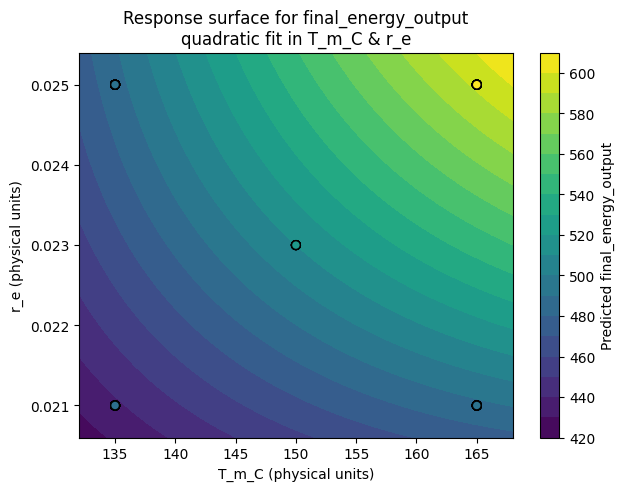

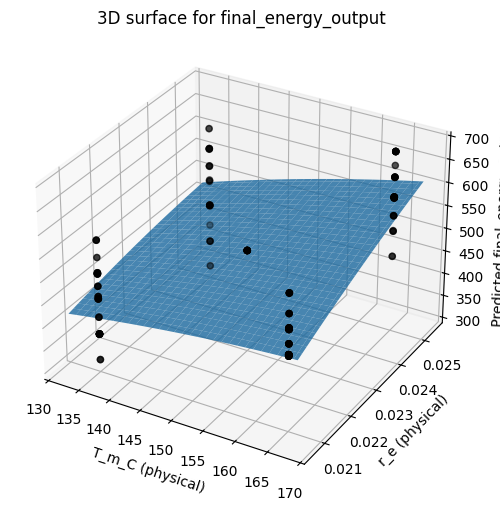

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# 1) Contour plot
plt.figure(figsize=(7, 5))
cp = plt.contourf(F1_phys, F2_phys, Yg, levels=20)
plt.colorbar(cp, label="Predicted final_energy_output")

plt.xlabel(f1 + " (physical units)")
plt.ylabel(f2 + " (physical units)")
plt.title("Response surface for final_energy_output\nquadratic fit in " + f1 + " & " + f2)

# Optionally overlay actual DOE points
plt.scatter(df[f1], df[f2], c=df["final_energy_output"], edgecolors="k", s=40)
plt.show()

# 2) 3D surface plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(F1_phys, F2_phys, Yg, alpha=0.8)
ax.set_xlabel(f1 + " (physical)")
ax.set_ylabel(f2 + " (physical)")
ax.set_zlabel("Predicted final_energy_output")
ax.set_title("3D surface for final_energy_output")

# Optional: scatter actual data in 3D
ax.scatter(df[f1], df[f2], df["final_energy_output"], color="k", s=20)
plt.show()
